#Cardio Vascular diseases

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
# Load the dataset
df = pd.read_csv("/content/CVD_dataset_with_Bmi.csv")

In [ ]:
df.head()

,ID,Gender,Age,Race_hispanic_origin,Race_NonHispanic_Asian_Category,Average_Drinks_Per_Drinking_Day_Past_12_Months,Dietary_habits,Diabetes_diagnosed,Overall_health,Smoking,CVD_Type,Ever_had_alcohol,Have_hypertension_or_highbp,Has_CVD,Weight,BMI
0,109317,2,28,2,2,3.0,4.0,0.0,2,0.0,0.0,1.0,0.0,0,91.6,30.1
1,109330,1,76,3,4,2.0,3.0,0.0,2,0.0,0.0,1.0,1.0,0,61.5,23.3
2,109335,2,55,2,2,6.0,3.0,0.0,3,2.0,0.0,1.0,1.0,0,107.2,39.6
3,109342,2,43,1,1,4.0,5.0,0.0,3,2.0,0.0,1.0,0.0,0,92.1,35.5
4,109379,2,66,1,1,2.0,4.0,1.0,3,0.0,0.0,1.0,1.0,0,83.2,33.4


In [ ]:
df.shape

(2028, 16)

##Logit (All variables)

In [ ]:
# Clean the data for the new, simplified model
model_vars_final = [
    'Has_CVD',
    'Gender','Age','Race_hispanic_origin','Race_NonHispanic_Asian_Category',
    'Diabetes_diagnosed','Dietary_habits','Overall_health','Smoking','Ever_had_alcohol', 'Have_hypertension_or_highbp',
    'Average_Drinks_Per_Drinking_Day_Past_12_Months',
    'Weight',
    'BMI'
]
df_clean_final = df.dropna(subset=model_vars_final)
# --- Define the final simplified formula ---
formula_final = (
    "Has_CVD ~ C(Gender) + (Age)+C(Race_hispanic_origin)+C(Race_NonHispanic_Asian_Category)+C(Diabetes_diagnosed)+C(Ever_had_alcohol)"
    "+C(Dietary_habits)+ C(Overall_health)+ C(Smoking)+ C(Have_hypertension_or_highbp)+(Weight) + (BMI) +Average_Drinks_Per_Drinking_Day_Past_12_Months"
)
# --- Fit the Final Logit Model ---
print("Fitting Final Logit Model (excluding Age and Average Drinks)...")
logit_model_final = smf.logit(formula_final, data=df_clean_final).fit()
# --- View the Model Summary ---
print(logit_model_final.summary())
# --- Get Odds Ratios ---
odds_ratios_final = pd.DataFrame(
    {
        "Odds Ratio": np.exp(logit_model_final.params),
        "P-Value": logit_model_final.pvalues,
        "Conf. Int. Lower": np.exp(logit_model_final.conf_int())[0],
        "Conf. Int. Upper": np.exp(logit_model_final.conf_int())[1],
    }
)
odds_ratios_final

Fitting Final Logit Model (excluding Age and Average Drinks)...
         Current function value: 0.317069
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                Has_CVD   No. Observations:                 2028
Model:                          Logit   Df Residuals:                     2003
Method:                           MLE   Df Model:                           24
Date:                Wed, 29 Oct 2025   Pseudo R-squ.:                  0.2435
Time:                        06:52:42   Log-Likelihood:                -643.02
converged:                      False   LL-Null:                       -849.93
Covariance Type:            nonrobust   LLR p-value:                 1.079e-72
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercep

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


,Odds Ratio,P-Value,Conf. Int. Lower,Conf. Int. Upper
Intercept,1.122876e-03,5.390354e-23,0.000292,0.004323
C(Gender)[T.2],4.878935e-01,1.458072e-10,0.391761,0.607616
C(Race_hispanic_origin)[T.2],8.756562e-01,1.000000e+00,0.000000,inf
C(Race_hispanic_origin)[T.3],5.707185e-01,1.000000e+00,0.000000,inf
C(Race_hispanic_origin)[T.4],7.225814e-01,NaN,NaN,NaN
C(Race_hispanic_origin)[T.5],6.438500e-01,1.000000e+00,0.000000,inf
C(Race_NonHispanic_Asian_Category)[T.2],8.756562e-01,1.000000e+00,0.000000,inf
C(Race_NonHispanic_Asian_Category)[T.3],7.225822e-01,NaN,NaN,NaN
C(Race_NonHispanic_Asian_Category)[T.4],5.971866e-01,1.000000e+00,0.000000,inf
C(Race_NonHispanic_Asian_Category)[T.5],6.438499e-01,1.000000e+00,0.000000,inf


##Logit (Significant features)

In [ ]:
# Clean the data for the new, simplified model
model_vars_final = [
    'Has_CVD',
    'Gender','Age',
    'Overall_health','Have_hypertension_or_highbp',
    ]
df_clean_final = df.dropna(subset=model_vars_final)
# --- Define the final simplified formula ---
formula_final = (
    "Has_CVD ~ C(Gender) + (Age)+C(Overall_health)+C(Have_hypertension_or_highbp)"
)
# --- Fit the Final Logit Model ---
print("Fitting Final Logit Model")
logit_model_final = smf.logit(formula_final, data=df_clean_final).fit()
# --- View the Model Summary ---
print(logit_model_final.summary())
# --- Get Odds Ratios ---
odds_ratios_final = pd.DataFrame(
    {
        "Odds Ratio": np.exp(logit_model_final.params),
        "P-Value": logit_model_final.pvalues,
        "Conf. Int. Lower": np.exp(logit_model_final.conf_int())[0],
        "Conf. Int. Upper": np.exp(logit_model_final.conf_int())[1],
    }
)

Fitting Final Logit Model
Optimization terminated successfully.
         Current function value: 0.327694
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                Has_CVD   No. Observations:                 2028
Model:                          Logit   Df Residuals:                     2020
Method:                           MLE   Df Model:                            7
Date:                Wed, 29 Oct 2025   Pseudo R-squ.:                  0.2181
Time:                        06:54:44   Log-Likelihood:                -664.56
converged:                       True   LL-Null:                       -849.93
Covariance Type:            nonrobust   LLR p-value:                 4.454e-76
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                   

##Probit (Significant variables)

In [ ]:
# Clean the data for the new, simplified model
model_vars_final = [
    'Has_CVD',
    'Gender','Age',
    'Overall_health','Have_hypertension_or_highbp',
]
df_clean_final = df.dropna(subset=model_vars_final)

# --- Define the final simplified formula ---
formula_final = (
    "Has_CVD ~ C(Gender) + (Age)+C(Overall_health)+C(Have_hypertension_or_highbp)"
)

# --- Fit the Final Probit Model ---
print("Fitting Final Probit Model")
probit_model_final = smf.probit(formula_final, data=df_clean_final).fit()

# --- View the Model Summary ---
print(probit_model_final.summary())

# --- Get Marginal Effects (more meaningful than odds ratios for Probit) ---
# For Probit, marginal effects are often more interpretable than coefficients
marginal_effects = probit_model_final.get_margeff()
print("\nMarginal Effects:")
print(marginal_effects.summary())

# If you still want coefficient-based metrics:
coefficients_summary = pd.DataFrame(
    {
        "Coefficient": probit_model_final.params,
        "P-Value": probit_model_final.pvalues,
        "Conf. Int. Lower": probit_model_final.conf_int()[0],
        "Conf. Int. Upper": probit_model_final.conf_int()[1],
    }
)
print("\nCoefficients Summary:")
print(coefficients_summary)

Fitting Final Probit Model
Optimization terminated successfully.
         Current function value: 0.327298
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:                Has_CVD   No. Observations:                 2028
Model:                         Probit   Df Residuals:                     2020
Method:                           MLE   Df Model:                            7
Date:                Wed, 29 Oct 2025   Pseudo R-squ.:                  0.2190
Time:                        08:21:00   Log-Likelihood:                -663.76
converged:                       True   LL-Null:                       -849.93
Covariance Type:            nonrobust   LLR p-value:                 2.018e-76
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                  

##Multinomial Logit for CVD Types

In [ ]:
# Clean the data for the multinomial logit model
model_vars_multinomial = [
    'CVD_Type',
    'Gender', 'Age',
    'Overall_health', 'Have_hypertension_or_highbp',
]
df_clean_multinomial = df.dropna(subset=model_vars_multinomial)

# --- Define the multinomial logit formula ---
formula_multinomial = (
    "CVD_Type ~ C(Gender) + Age + C(Overall_health) + C(Have_hypertension_or_highbp)"
)

# --- Fit the Multinomial Logit Model ---
print("Fitting Multinomial Logit Model")
multinomial_model = smf.mnlogit(formula_multinomial, data=df_clean_multinomial).fit()

# --- View the Model Summary ---
print(multinomial_model.summary())

# --- Get Odds Ratios ---
odds_ratios_multinomial = pd.DataFrame(
    {
        "Odds Ratio": np.exp(multinomial_model.params),
        "P-Value": multinomial_model.pvalues,
        "Conf. Int. Lower": np.exp(multinomial_model.conf_int())[0],
        "Conf. Int. Upper": np.exp(multinomial_model.conf_int())[1],
    }
)

print("\nOdds Ratios:")
odds_ratios_multinomial

Fitting Multinomial Logit Model
         Current function value: 0.525961
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                          MNLogit Regression Results                          
Dep. Variable:               CVD_Type   No. Observations:                 2028
Model:                        MNLogit   Df Residuals:                     1988
Method:                           MLE   Df Model:                           35
Date:                Wed, 29 Oct 2025   Pseudo R-squ.:                  0.1684
Time:                        08:27:56   Log-Likelihood:                -1066.6
converged:                      False   LL-Null:                       -1282.7
Covariance Type:            nonrobust   LLR p-value:                 6.424e-70
                           CVD_Type=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                               -27.0697   4794.483     -0.006      0.995   -9424.084    9369.944
C(Gender)[T.2]                           -0.3077  

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


KeyError: 0

In [ ]:
# First, let's examine the CVD_Type variable
print("CVD_Type value counts:")
print(df_clean_multinomial['CVD_Type'].value_counts())
print(f"\nNumber of unique CVD_Type values: {df_clean_multinomial['CVD_Type'].nunique()}")

# Check for any unusual values or categories with very few observations
print("\nCVD_Type distribution:")
print(df_clean_multinomial['CVD_Type'].value_counts(normalize=True))

# Let's also check the other categorical variables
print("\nOverall_health value counts:")
print(df_clean_multinomial['Overall_health'].value_counts())

print("\nHave_hypertension_or_highbp value counts:")
print(df_clean_multinomial['Have_hypertension_or_highbp'].value_counts())

CVD_Type value counts:
CVD_Type
0.0    1728
5.0     128
4.0      70
1.0      37
3.0      34
2.0      31
Name: count, dtype: int64

Number of unique CVD_Type values: 6

CVD_Type distribution:
CVD_Type
0.0    0.852071
5.0    0.063116
4.0    0.034517
1.0    0.018245
3.0    0.016765
2.0    0.015286
Name: proportion, dtype: float64

Overall_health value counts:
Overall_health
3    795
2    513
4    460
1    167
5     93
Name: count, dtype: int64

Have_hypertension_or_highbp value counts:
Have_hypertension_or_highbp
0.0    1089
1.0     939
Name: count, dtype: int64


#Liver Models

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# Load the dataset
df = pd.read_csv("cleaned_liver_data_1.csv")
df.shape

(546, 18)

##Logit Model

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# Load the dataset
df = pd.read_csv("cleaned_liver_data_1.csv")

# Clean the data for the new, simplified model
model_vars_final = [
    'Has_liver_disease',
    'Gender',
    'Diabetes_diagnosed_binary',
    'Diagnosed_with_hypertension_or_highbp',
    'Average_Drinks_Per_Drinking_Day_Past_12_Months',
    'Weight',
    'BMI'

]
df_clean_final = df.dropna(subset=model_vars_final)


# --- Define the final simplified formula ---
formula_final = (
    "Has_liver_disease ~ C(Gender) + "
    "C(Diabetes_diagnosed_binary) + C(Diagnosed_with_hypertension_or_highbp) + (Weight) + (BMI) +Average_Drinks_Per_Drinking_Day_Past_12_Months"
)

# --- Fit the Final Logit Model ---
print("Fitting Final Logit Model ")

logit_model_final = smf.logit(formula_final, data=df_clean_final).fit()

# --- View the Model Summary ---
print(logit_model_final.summary())

# --- Get Odds Ratios ---
odds_ratios_final = pd.DataFrame(
    {
        "Odds Ratio": np.exp(logit_model_final.params),
        "P-Value": logit_model_final.pvalues,
        "Conf. Int. Lower": np.exp(logit_model_final.conf_int())[0],
        "Conf. Int. Upper": np.exp(logit_model_final.conf_int())[1],
    }
)

print("\n--- Odds Ratios (Final Simplified Model) ---")
odds_ratios_final

Fitting Final Logit Model 
Optimization terminated successfully.
         Current function value: 0.442128
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:      Has_liver_disease   No. Observations:                  535
Model:                          Logit   Df Residuals:                      528
Method:                           MLE   Df Model:                            6
Date:                Wed, 29 Oct 2025   Pseudo R-squ.:                  0.3594
Time:                        08:38:44   Log-Likelihood:                -236.54
converged:                       True   LL-Null:                       -369.26
Covariance Type:            nonrobust   LLR p-value:                 2.045e-54
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept

,Odds Ratio,P-Value,Conf. Int. Lower,Conf. Int. Upper
Intercept,0.146970,8.377376e-05,0.056528,0.382115
C(Gender)[T.2],0.756222,3.862138e-01,0.401942,1.422771
C(Diabetes_diagnosed_binary)[T.1.0],9.972046,4.538576e-07,4.080838,24.367960
C(Diagnosed_with_hypertension_or_highbp)[T.1],24.311243,3.911925e-20,12.310302,48.011538
Weight,0.957454,1.539021e-02,0.924368,0.991725
BMI,1.156513,5.440559e-03,1.043815,1.281379
Average_Drinks_Per_Drinking_Day_Past_12_Months,1.124405,3.776013e-02,1.006653,1.255931


##Probit for Liver disease

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# Load the dataset
df = pd.read_csv("cleaned_liver_data_1.csv")

# Clean the data for the new, simplified model
model_vars_final = [
    'Has_liver_disease',
    'Gender',
    'Diabetes_diagnosed_binary',
    'Diagnosed_with_hypertension_or_highbp',
    'Average_Drinks_Per_Drinking_Day_Past_12_Months',
    'Weight',
    'BMI'

]
df_clean_final = df.dropna(subset=model_vars_final)

# --- Define the final simplified formula ---
formula_final = (
    "Has_liver_disease ~ C(Gender) + "
    "C(Diabetes_diagnosed_binary) + C(Diagnosed_with_hypertension_or_highbp) + (Weight) + (BMI) +Average_Drinks_Per_Drinking_Day_Past_12_Months"
)


# --- Fit the Final Probit Model ---
print("Fitting Final Probit Model")
probit_model_final = smf.probit(formula_final, data=df_clean_final).fit()

# --- View the Model Summary ---
print(probit_model_final.summary())

# --- Get Marginal Effects (more meaningful than odds ratios for Probit) ---
# For Probit, marginal effects are often more interpretable than coefficients
marginal_effects = probit_model_final.get_margeff()
print("\nMarginal Effects:")
print(marginal_effects.summary())

# If you still want coefficient-based metrics:
coefficients_summary = pd.DataFrame(
    {
        "Coefficient": probit_model_final.params,
        "P-Value": probit_model_final.pvalues,
        "Conf. Int. Lower": probit_model_final.conf_int()[0],
        "Conf. Int. Upper": probit_model_final.conf_int()[1],
    }
)
print("\nCoefficients Summary:")
print(coefficients_summary)

Fitting Final Probit Model
Optimization terminated successfully.
         Current function value: 0.444514
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:      Has_liver_disease   No. Observations:                  535
Model:                         Probit   Df Residuals:                      528
Method:                           MLE   Df Model:                            6
Date:                Wed, 29 Oct 2025   Pseudo R-squ.:                  0.3560
Time:                        12:35:11   Log-Likelihood:                -237.82
converged:                       True   LL-Null:                       -369.26
Covariance Type:            nonrobust   LLR p-value:                 7.191e-54
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept

##Multinomial Logit for Liver disease type

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# Load the dataset
df = pd.read_csv("cleaned_liver_data_1.csv")

# Clean data: Liver_condition_type has NaNs for people without liver disease
# We must ensure the '0.0' (No Disease) group is included for the baseline
# The Liver_condition_type variable in the provided data appears to be 0.0 for those
# without the condition, and 1.0 to 7.0 for those with (based on prior context).

model_vars_mnl = [
    'Liver_condition_type',
    'Gender',
    'Diabetes_diagnosed_binary',
    'Diagnosed_with_hypertension_or_highbp',
    'Average_Drinks_Per_Drinking_Day_Past_12_Months',
    'Weight',
    'BMI'
]

# Note: We include rows where Liver_condition_type is 0.0, as these are non-disease cases (our baseline)
df_clean_mnl = df.dropna(subset=model_vars_mnl)

# --- Define the Multinomial Logit Formula ---
# We will exclude 'Age' and 'Drinks' again to ensure convergence
formula_mnl = (
    "Liver_condition_type ~ C(Gender) + "
    "C(Diabetes_diagnosed_binary) + C(Diagnosed_with_hypertension_or_highbp)+(Weight) + (BMI)"
)

# --- Fit the Multinomial Logit Model ---
print("Fitting Multinomial Logit Model for Liver Condition Type...")

# Use 'MNLogit' for Multinomial Logit. By default, it uses the first category (0.0: No Disease) as the reference.
mnl_model = smf.mnlogit(formula_mnl, data=df_clean_mnl).fit()

# --- View the Model Summary ---
print(mnl_model.summary())

Fitting Multinomial Logit Model for Liver Condition Type...
Optimization terminated successfully.
         Current function value: nan
         Iterations 5


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3028: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]


                           MNLogit Regression Results                           
Dep. Variable:     Liver_condition_type   No. Observations:                  535
Model:                          MNLogit   Df Residuals:                      493
Method:                             MLE   Df Model:                           35
Date:                  Wed, 29 Oct 2025   Pseudo R-squ.:                     nan
Time:                          08:44:31   Log-Likelihood:                    nan
converged:                         True   LL-Null:                       -722.89
Covariance Type:              nonrobust   LLR p-value:                       nan
                       Liver_condition_type=1       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                            nan        nan        nan        nan         nan         nan
C(Gender)[

##Multinomial Logit for collapsed liver disease type

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# Load the dataset
df = pd.read_csv("cleaned_liver_data_1.csv")

# --- 1. Create the Collapsed Outcome Variable ---
def collapse_liver_type(lc_type):
    if lc_type == 0.0:
        return 0  # No Disease (Baseline)
    elif lc_type == 1.0:
        return 1  # Viral
    elif lc_type == 2.0:
        return 2  # Fatty Liver
    elif lc_type >= 3.0:
        return 3  # Other/Advanced (Includes 3, 4, 5, 6, 7)
    return np.nan # Catch any unexpected NaNs

df['Liver_Type_Collapsed'] = df['Liver_condition_type'].apply(collapse_liver_type)

# --- 2. Clean Data and Define Formula ---
model_vars_mnl = [
    'Liver_Type_Collapsed',
    'Gender',
    'Diabetes_diagnosed_binary',
    'Diagnosed_with_hypertension_or_highbp',
    'Average_Drinks_Per_Drinking_Day_Past_12_Months',
    'Weight',
    'BMI'
]

# Drop rows where the collapsed variable is NaN
df_clean_mnl_collapsed = df.dropna(subset=model_vars_mnl)

# Use the collapsed variable in the formula
formula_mnl_collapsed = (
    "Liver_Type_Collapsed ~ C(Gender) + "
    "C(Diabetes_diagnosed_binary) + C(Diagnosed_with_hypertension_or_highbp)  + (Weight) + (BMI) +Average_Drinks_Per_Drinking_Day_Past_12_Months"
)

# --- 3. Fit the Collapsed Multinomial Logit Model ---
print("Fitting Multinomial Logit Model with Collapsed Categories...")

# 'MNLogit' uses the lowest-coded category (0) as the reference (No Disease).
mnl_model_collapsed = smf.mnlogit(formula_mnl_collapsed, data=df_clean_mnl_collapsed).fit()

# --- 4. View the Model Summary ---
print(mnl_model_collapsed.summary())

Fitting Multinomial Logit Model with Collapsed Categories...
Optimization terminated successfully.
         Current function value: 0.871111
         Iterations 6
                           MNLogit Regression Results                           
Dep. Variable:     Liver_Type_Collapsed   No. Observations:                  535
Model:                          MNLogit   Df Residuals:                      514
Method:                             MLE   Df Model:                           18
Date:                  Wed, 29 Oct 2025   Pseudo R-squ.:                  0.2497
Time:                          08:45:08   Log-Likelihood:                -466.04
converged:                         True   LL-Null:                       -621.16
Covariance Type:              nonrobust   LLR p-value:                 3.770e-55
                        Liver_Type_Collapsed=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

#CVD EDA

Dataset Shape: (2028, 16)

First few rows:
       ID  Gender  Age  Race_hispanic_origin  Race_NonHispanic_Asian_Category  \
0  109317       2   28                     2                                2   
1  109330       1   76                     3                                4   
2  109335       2   55                     2                                2   
3  109342       2   43                     1                                1   
4  109379       2   66                     1                                1   

   Average_Drinks_Per_Drinking_Day_Past_12_Months  Dietary_habits  \
0                                             3.0             4.0   
1                                             2.0             3.0   
2                                             6.0             3.0   
3                                             4.0             5.0   
4                                             2.0             4.0   

   Diabetes_diagnosed  Overall_health  Smoking  CVD_Typ

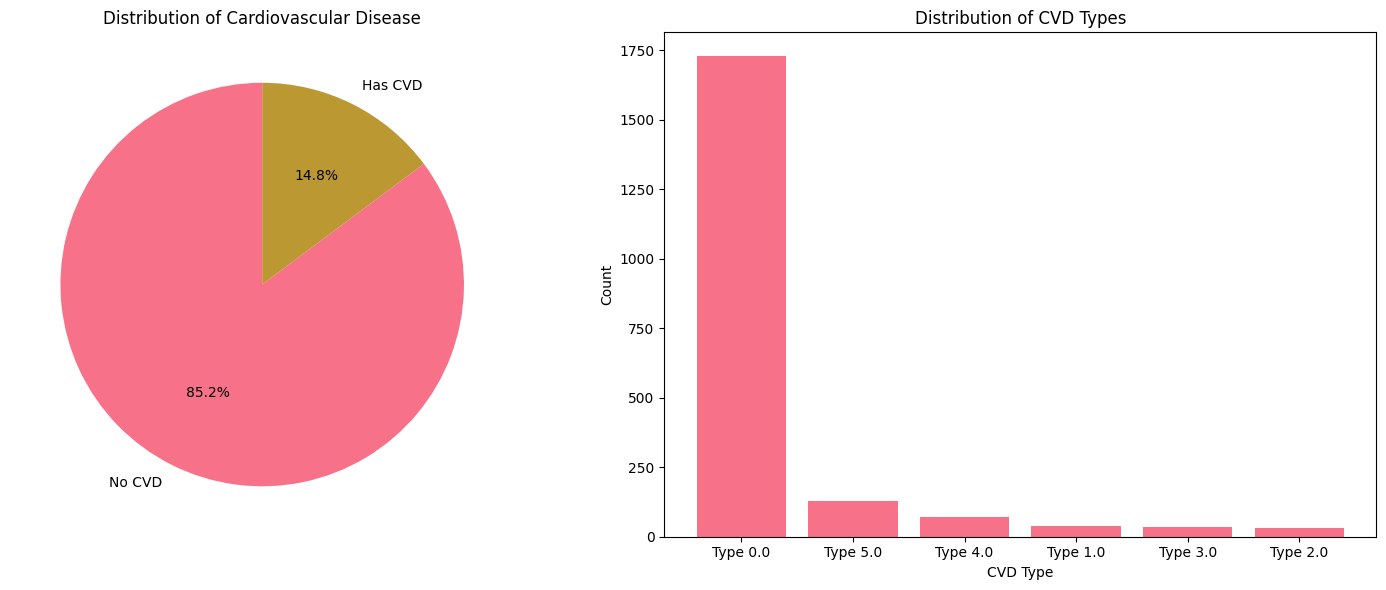

CVD Prevalence: 14.79%
Most common CVD type: Type 0.0 (1728 cases)

2. DEMOGRAPHIC ANALYSIS BY CVD STATUS


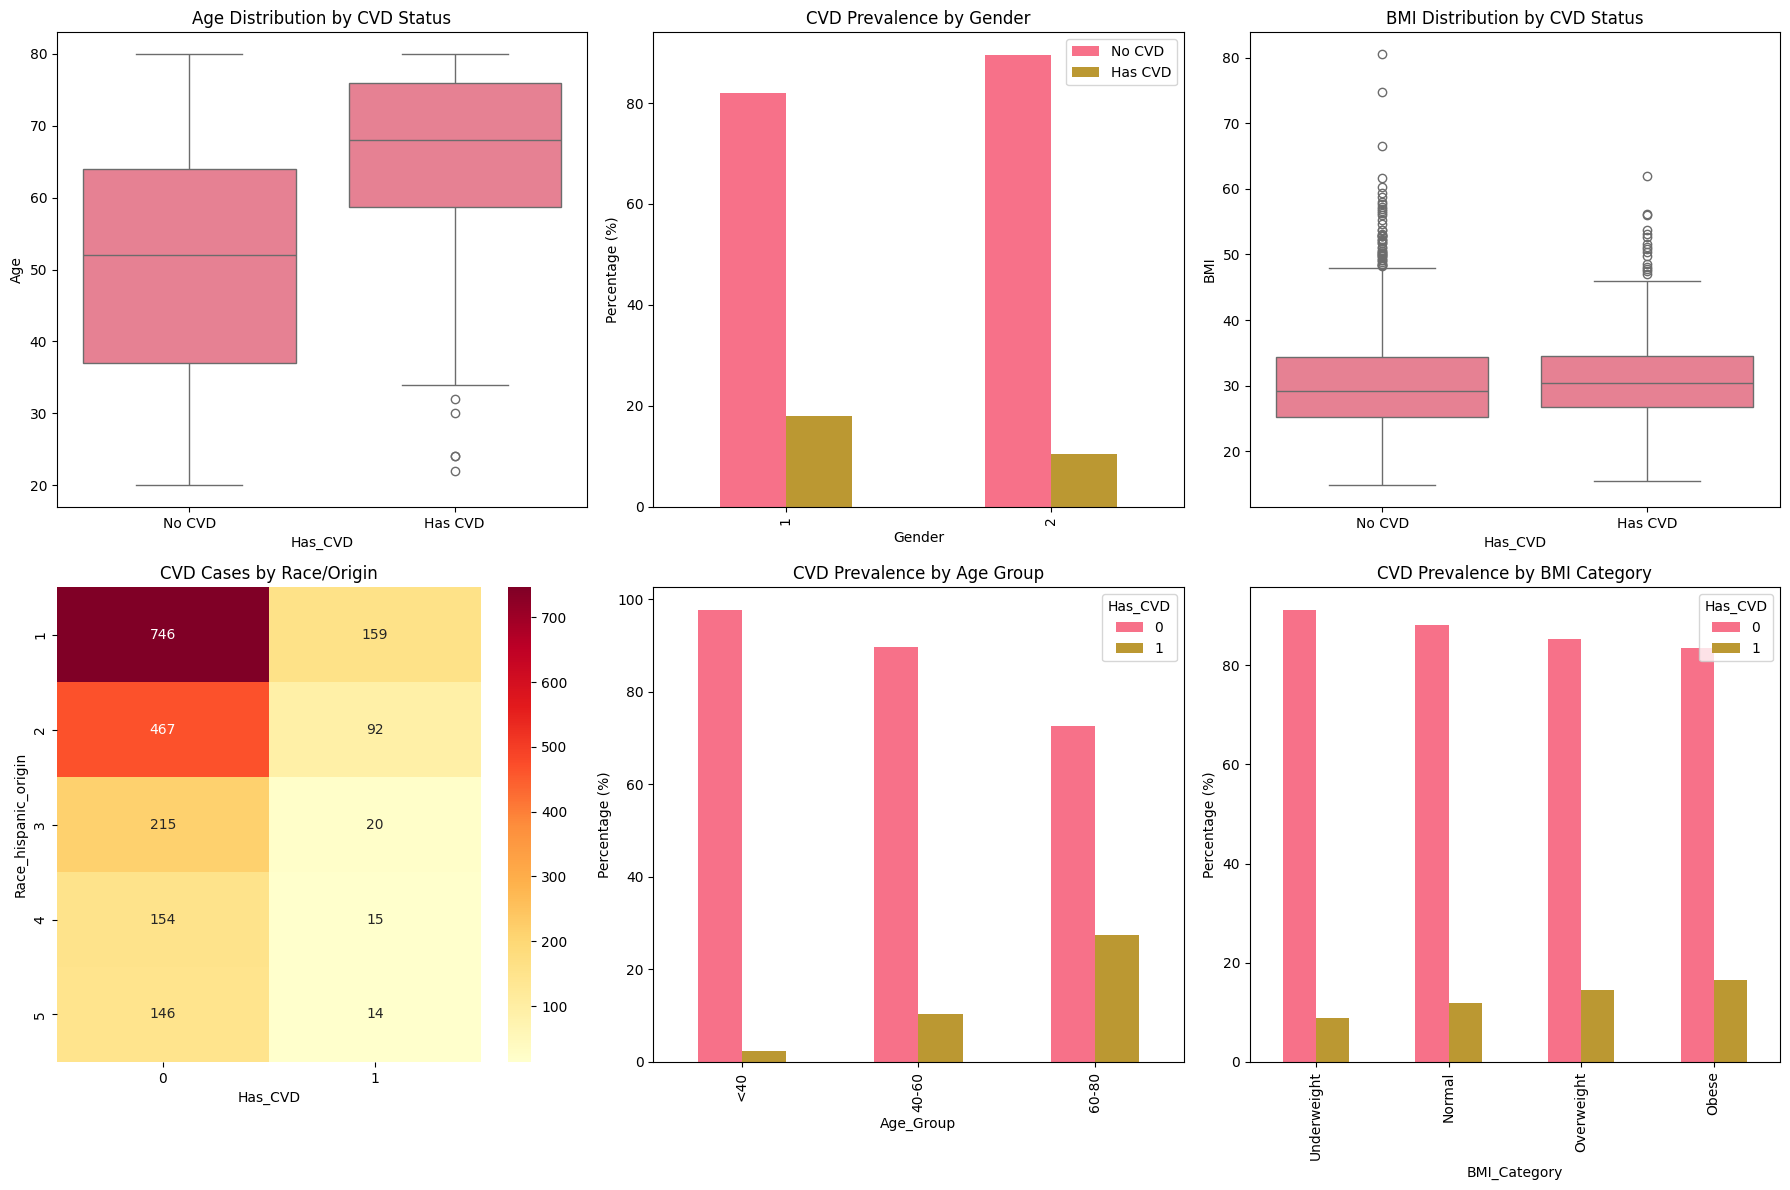


Statistical Tests for Demographics:
Age difference t-test: t-statistic = 15.176, p-value = 0.0000
BMI difference t-test: t-statistic = 1.993, p-value = 0.0464

3. HEALTH CONDITIONS ANALYSIS


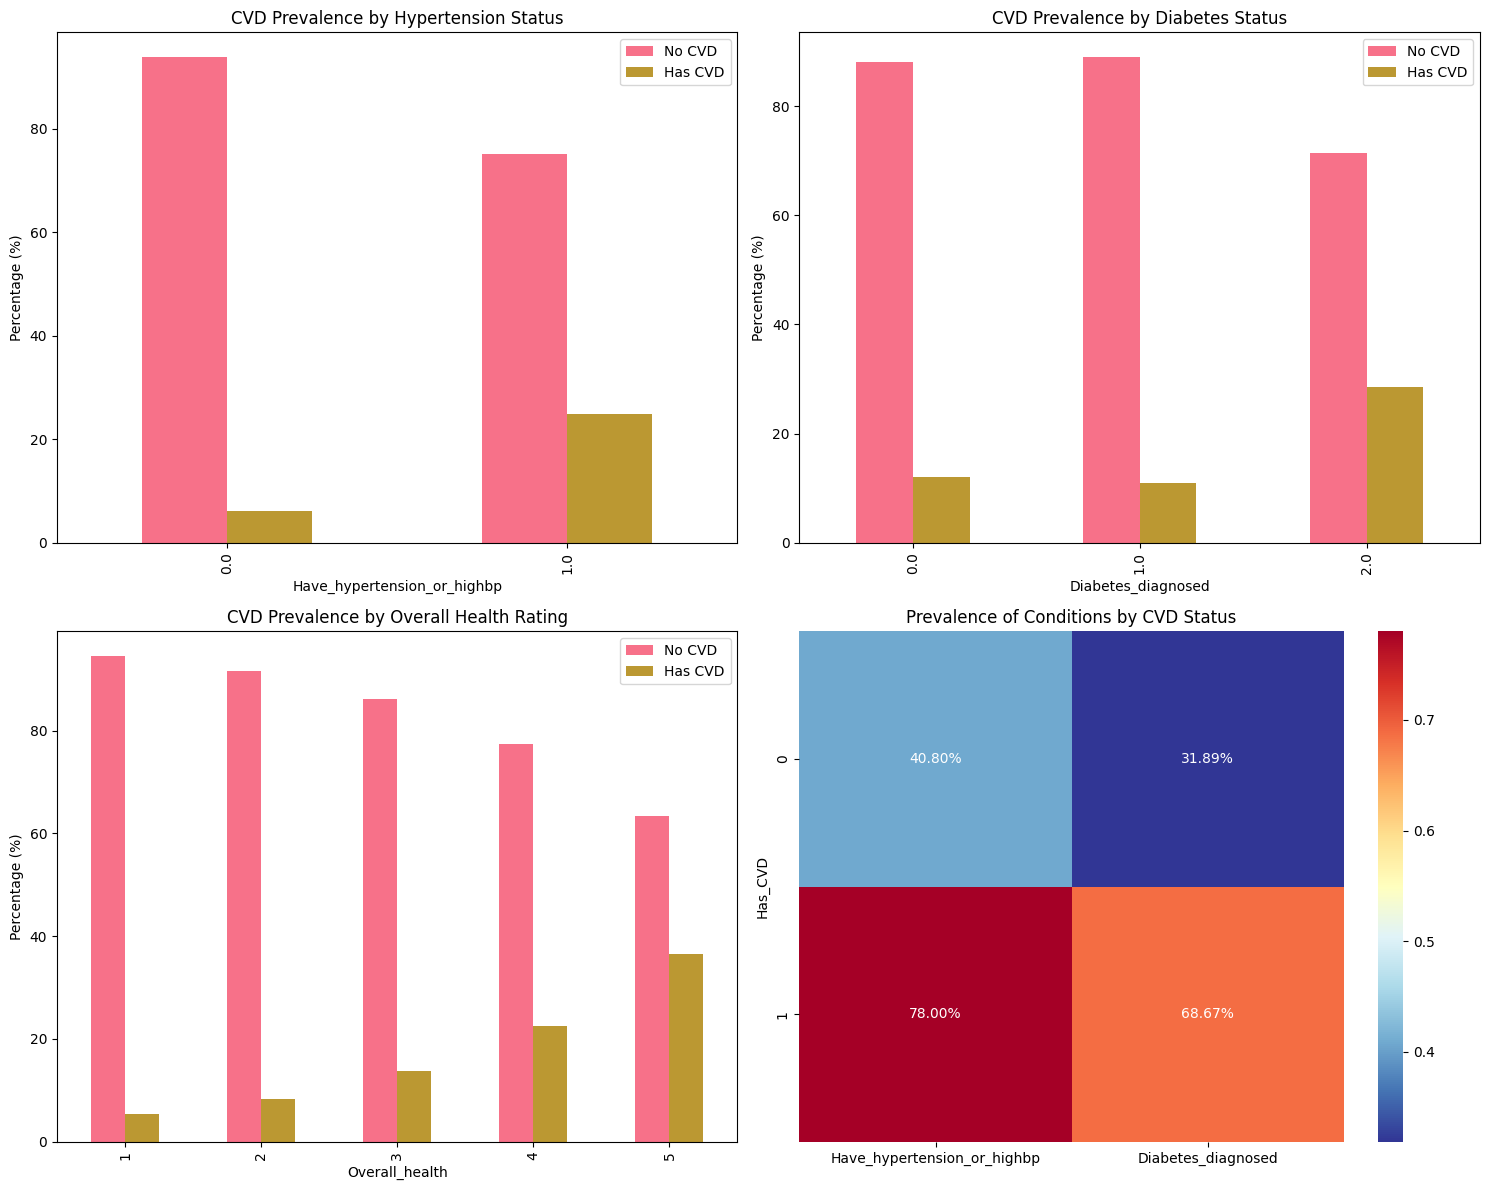


4. LIFESTYLE FACTORS ANALYSIS


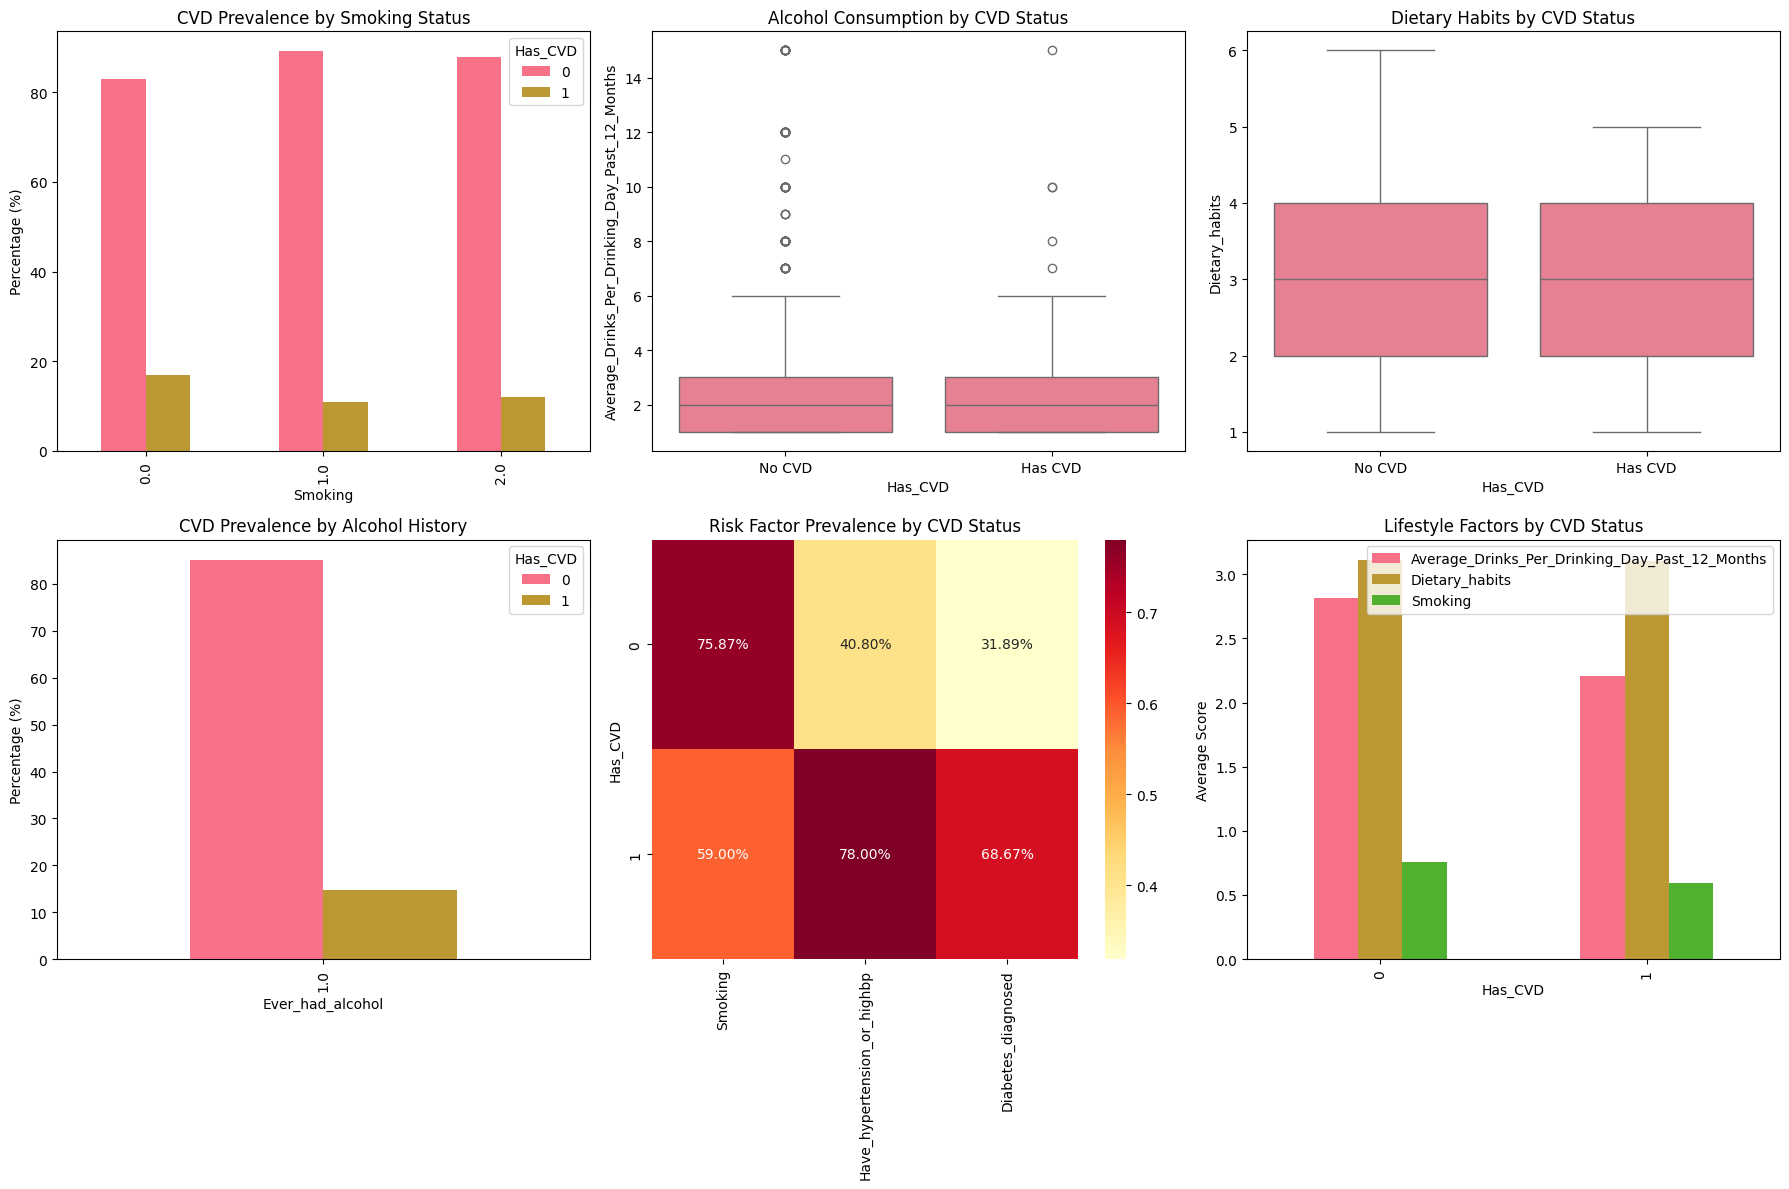


5. CORRELATION ANALYSIS


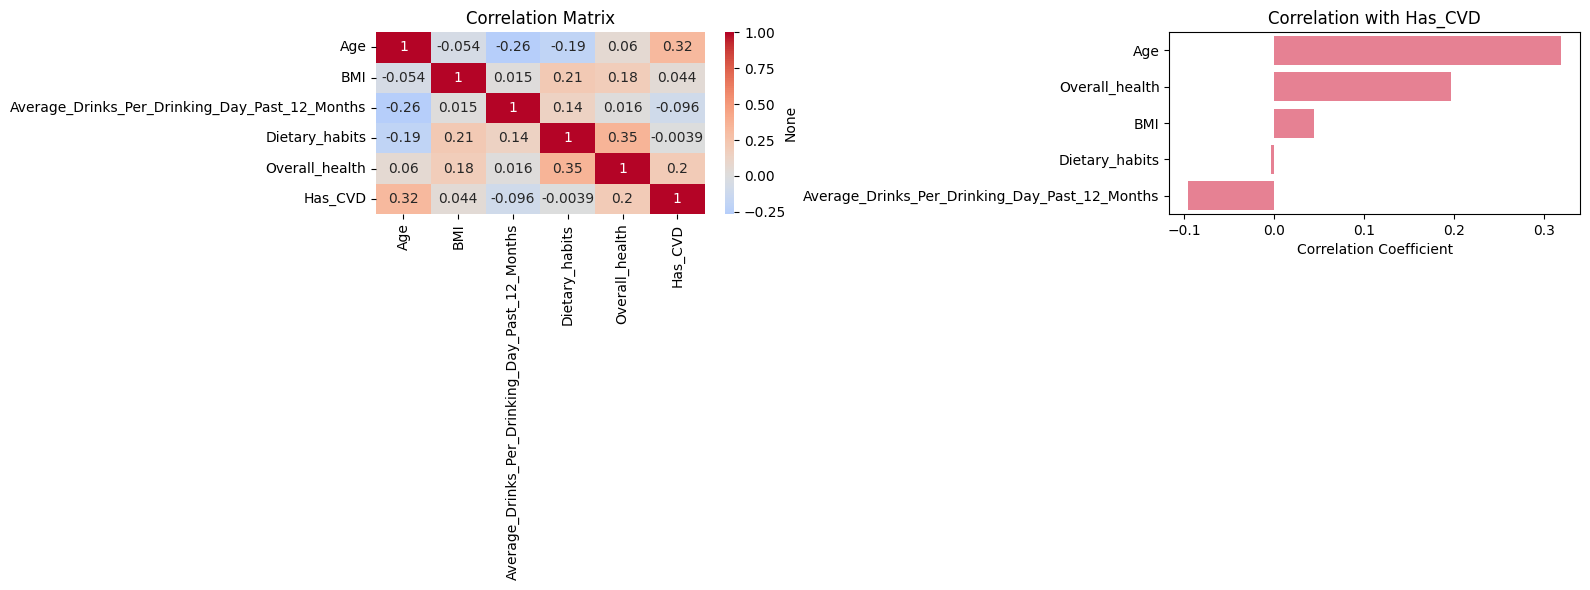

Top positive correlations with Has_CVD:
Age                                               0.319483
Overall_health                                    0.197168
BMI                                               0.044230
Dietary_habits                                   -0.003902
Average_Drinks_Per_Drinking_Day_Past_12_Months   -0.096008
Name: Has_CVD, dtype: float64

6. MULTIVARIATE ANALYSIS - RISK PROFILES


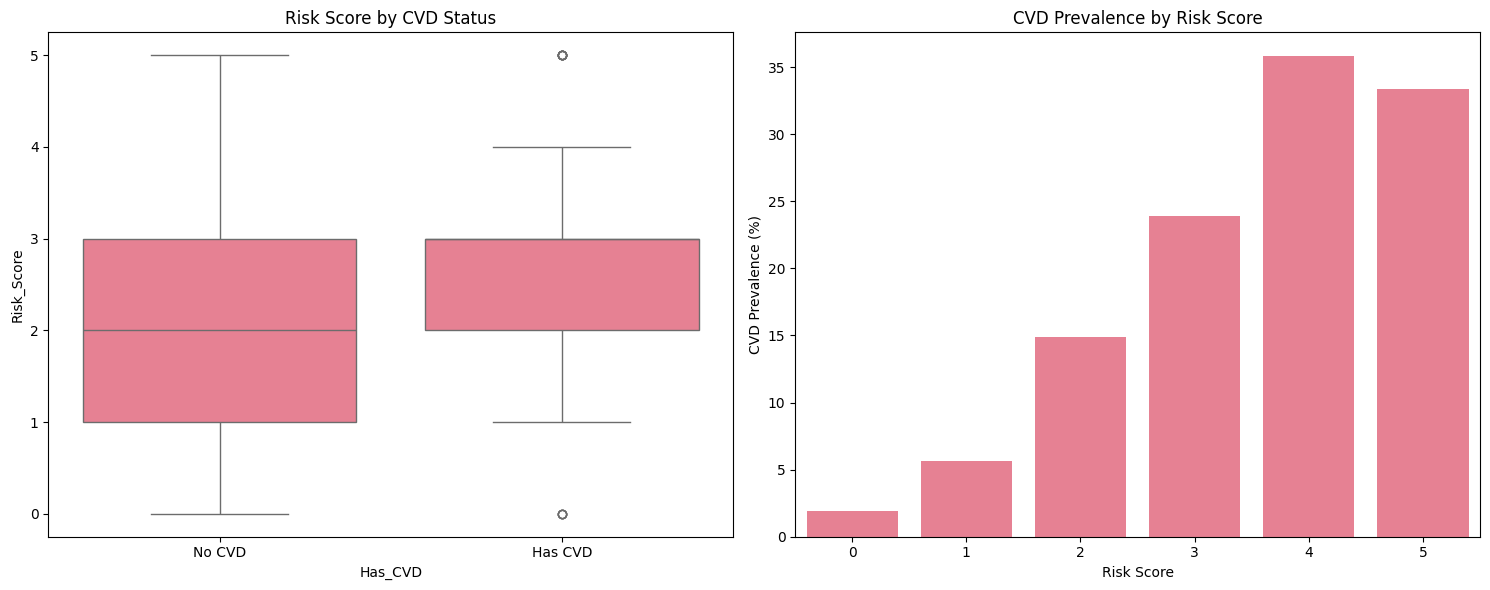


CVD Prevalence by Risk Score:
Risk Score 0: 2.0% (205 people)
Risk Score 1: 5.6% (586 people)
Risk Score 2: 14.9% (617 people)
Risk Score 3: 23.9% (423 people)
Risk Score 4: 35.8% (176 people)
Risk Score 5: 33.3% (21 people)

7. DETAILED STATISTICAL SUMMARY
Summary Statistics by CVD Status:
              Age                   BMI            \
             mean        std       mean       std   
Has_CVD                                             
0        50.80787  16.308978  30.315220  7.634456   
1        65.80000  12.415332  31.263333  7.443957   

        Average_Drinks_Per_Drinking_Day_Past_12_Months            \
                                                  mean       std   
Has_CVD                                                            
0                                             2.814815  2.321664   
1                                             2.206667  1.689221   

        Dietary_habits           Overall_health             Smoking            
                  me

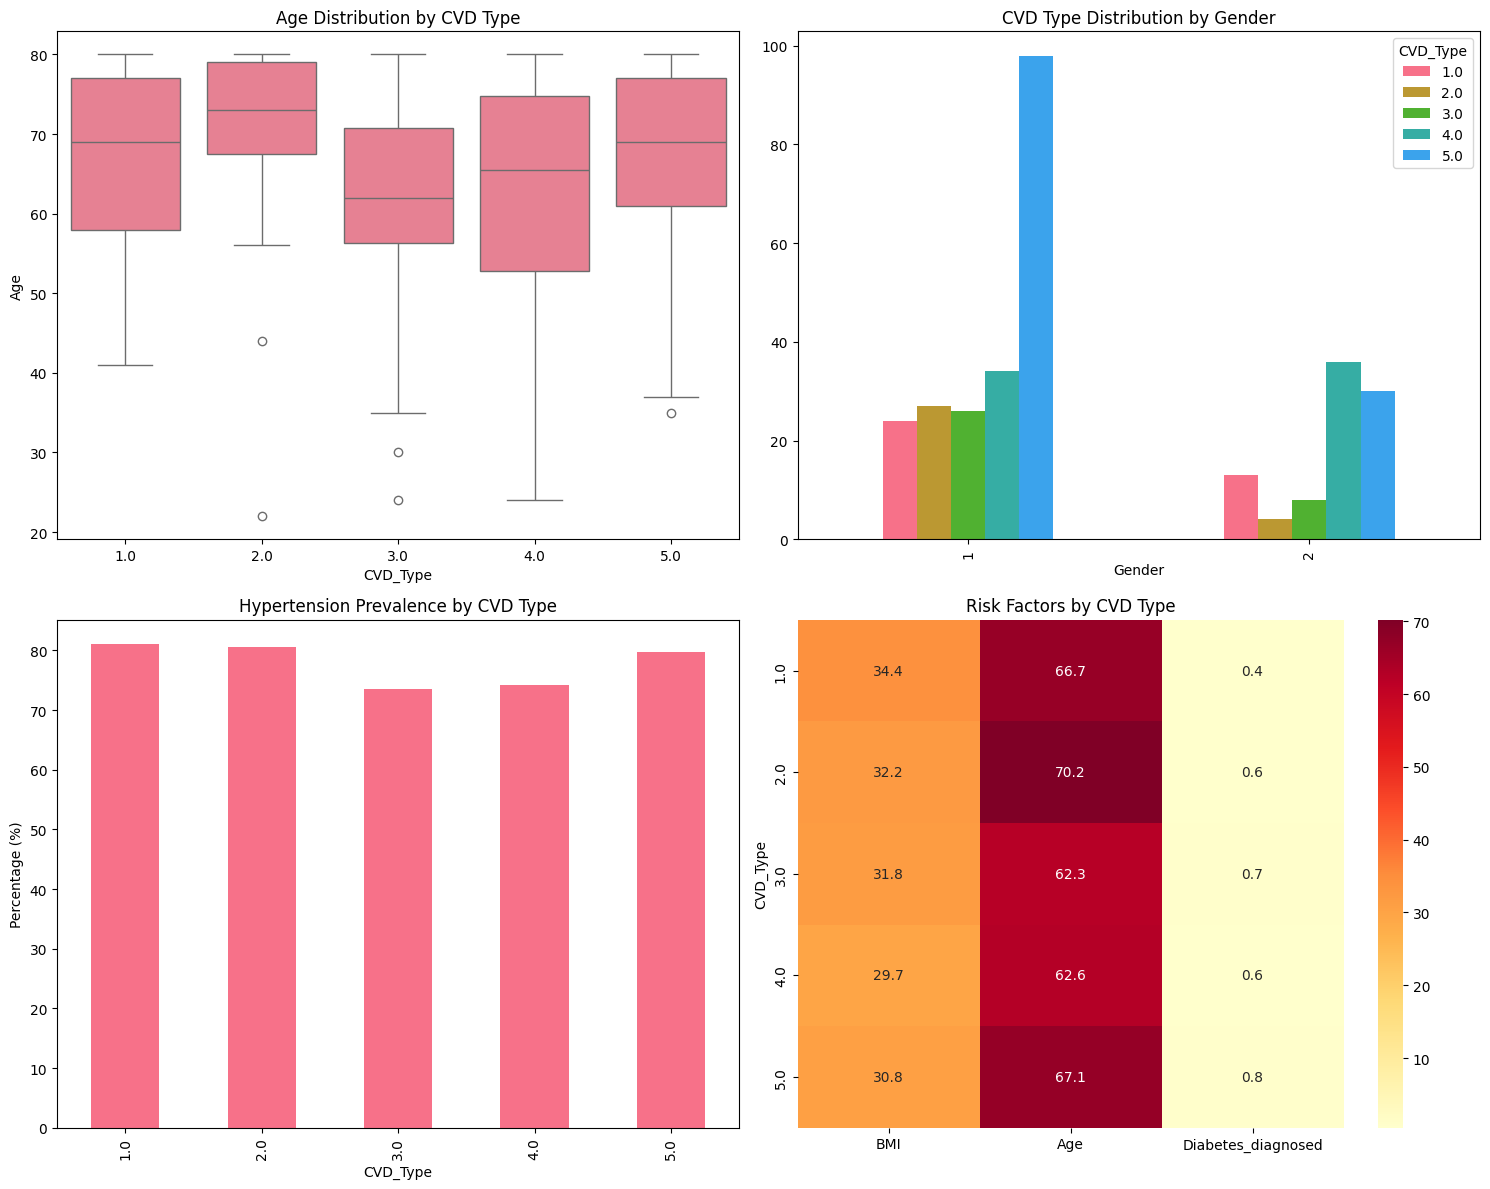


KEY INSIGHTS SUMMARY
• Total sample size: 2028
• CVD cases: 300 (14.8% prevalence)
• Most common CVD type: Type 5.0
• Average age: 53.0 years
• Average BMI: 30.5
• Hypertension prevalence: 46.3%
• Significant risk factors (p < 0.05): Check statistical tests above

Summary statistics saved for reporting


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('CVD_dataset_with_Bmi.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# 1. TARGET VARIABLE ANALYSIS
print("="*50)
print("1. TARGET VARIABLE ANALYSIS")
print("="*50)

# Has_CVD distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Has_CVD pie chart
cvd_counts = df['Has_CVD'].value_counts()
axes[0].pie(cvd_counts.values, labels=['No CVD', 'Has CVD'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribution of Cardiovascular Disease')

# CVD_Type distribution
cvd_type_counts = df['CVD_Type'].value_counts()
axes[1].bar(range(len(cvd_type_counts)), cvd_type_counts.values)
axes[1].set_title('Distribution of CVD Types')
axes[1].set_xlabel('CVD Type')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(len(cvd_type_counts)))
axes[1].set_xticklabels([f'Type {i}' for i in cvd_type_counts.index])

plt.tight_layout()
plt.show()

print(f"CVD Prevalence: {df['Has_CVD'].mean():.2%}")
print(f"Most common CVD type: Type {cvd_type_counts.index[0]} ({cvd_type_counts.iloc[0]} cases)")

# 2. DEMOGRAPHIC ANALYSIS BY CVD STATUS
print("\n" + "="*50)
print("2. DEMOGRAPHIC ANALYSIS BY CVD STATUS")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Age distribution by CVD status
sns.boxplot(data=df, x='Has_CVD', y='Age', ax=axes[0,0])
axes[0,0].set_title('Age Distribution by CVD Status')
axes[0,0].set_xticklabels(['No CVD', 'Has CVD'])

# Gender distribution by CVD status
gender_cvd = pd.crosstab(df['Gender'], df['Has_CVD'], normalize='index') * 100
gender_cvd.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('CVD Prevalence by Gender')
axes[0,1].set_xlabel('Gender')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].legend(['No CVD', 'Has CVD'])

# BMI distribution by CVD status
sns.boxplot(data=df, x='Has_CVD', y='BMI', ax=axes[0,2])
axes[0,2].set_title('BMI Distribution by CVD Status')
axes[0,2].set_xticklabels(['No CVD', 'Has CVD'])

# Race distribution by CVD status
race_cvd = pd.crosstab(df['Race_hispanic_origin'], df['Has_CVD'])
sns.heatmap(race_cvd, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,0])
axes[1,0].set_title('CVD Cases by Race/Origin')

# Age groups analysis
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 40, 60, 80, 100], labels=['<40', '40-60', '60-80', '80+'])
age_cvd = pd.crosstab(df['Age_Group'], df['Has_CVD'], normalize='index') * 100
age_cvd.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('CVD Prevalence by Age Group')
axes[1,1].set_ylabel('Percentage (%)')

# BMI categories
df['BMI_Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
bmi_cvd = pd.crosstab(df['BMI_Category'], df['Has_CVD'], normalize='index') * 100
bmi_cvd.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('CVD Prevalence by BMI Category')
axes[1,2].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

# Statistical tests for demographics
print("\nStatistical Tests for Demographics:")
t_stat, p_val = stats.ttest_ind(
    df[df['Has_CVD'] == 1]['Age'],
    df[df['Has_CVD'] == 0]['Age']
)
print(f"Age difference t-test: t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")

t_stat_bmi, p_val_bmi = stats.ttest_ind(
    df[df['Has_CVD'] == 1]['BMI'],
    df[df['Has_CVD'] == 0]['BMI']
)
print(f"BMI difference t-test: t-statistic = {t_stat_bmi:.3f}, p-value = {p_val_bmi:.4f}")

# 3. HEALTH CONDITIONS ANALYSIS
print("\n" + "="*50)
print("3. HEALTH CONDITIONS ANALYSIS")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Hypertension by CVD status
hypertension_cvd = pd.crosstab(df['Have_hypertension_or_highbp'], df['Has_CVD'], normalize='index') * 100
hypertension_cvd.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('CVD Prevalence by Hypertension Status')
axes[0,0].set_ylabel('Percentage (%)')
axes[0,0].legend(['No CVD', 'Has CVD'])

# Diabetes by CVD status
diabetes_cvd = pd.crosstab(df['Diabetes_diagnosed'], df['Has_CVD'], normalize='index') * 100
diabetes_cvd.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('CVD Prevalence by Diabetes Status')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].legend(['No CVD', 'Has CVD'])

# Overall health by CVD status
health_cvd = pd.crosstab(df['Overall_health'], df['Has_CVD'], normalize='index') * 100
health_cvd.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('CVD Prevalence by Overall Health Rating')
axes[1,0].set_ylabel('Percentage (%)')
axes[1,0].legend(['No CVD', 'Has CVD'])

# Multiple conditions heatmap
conditions_data = df.groupby('Has_CVD')[['Have_hypertension_or_highbp', 'Diabetes_diagnosed']].mean()
sns.heatmap(conditions_data, annot=True, fmt='.2%', cmap='RdYlBu_r', ax=axes[1,1])
axes[1,1].set_title('Prevalence of Conditions by CVD Status')

plt.tight_layout()
plt.show()

# 4. LIFESTYLE FACTORS ANALYSIS
print("\n" + "="*50)
print("4. LIFESTYLE FACTORS ANALYSIS")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Smoking by CVD status
smoking_cvd = pd.crosstab(df['Smoking'], df['Has_CVD'], normalize='index') * 100
smoking_cvd.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('CVD Prevalence by Smoking Status')
axes[0,0].set_ylabel('Percentage (%)')

# Alcohol consumption by CVD status
sns.boxplot(data=df, x='Has_CVD', y='Average_Drinks_Per_Drinking_Day_Past_12_Months', ax=axes[0,1])
axes[0,1].set_title('Alcohol Consumption by CVD Status')
axes[0,1].set_xticklabels(['No CVD', 'Has CVD'])

# Dietary habits by CVD status
sns.boxplot(data=df, x='Has_CVD', y='Dietary_habits', ax=axes[0,2])
axes[0,2].set_title('Dietary Habits by CVD Status')
axes[0,2].set_xticklabels(['No CVD', 'Has CVD'])

# Ever had alcohol by CVD status
alcohol_ever_cvd = pd.crosstab(df['Ever_had_alcohol'], df['Has_CVD'], normalize='index') * 100
alcohol_ever_cvd.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('CVD Prevalence by Alcohol History')
axes[1,0].set_ylabel('Percentage (%)')

# Risk factors combination
risk_factors = df.groupby('Has_CVD').agg({
    'Smoking': 'mean',
    'Have_hypertension_or_highbp': 'mean',
    'Diabetes_diagnosed': 'mean'
})
sns.heatmap(risk_factors, annot=True, fmt='.2%', cmap='YlOrRd', ax=axes[1,1])
axes[1,1].set_title('Risk Factor Prevalence by CVD Status')

# Lifestyle summary statistics
lifestyle_stats = df.groupby('Has_CVD').agg({
    'Average_Drinks_Per_Drinking_Day_Past_12_Months': 'mean',
    'Dietary_habits': 'mean',
    'Smoking': 'mean'
})
lifestyle_stats.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Lifestyle Factors by CVD Status')
axes[1,2].set_ylabel('Average Score')

plt.tight_layout()
plt.show()

# 5. CORRELATION ANALYSIS
print("\n" + "="*50)
print("5. CORRELATION ANALYSIS")
print("="*50)

# Select numerical columns for correlation
numerical_cols = ['Age', 'BMI', 'Average_Drinks_Per_Drinking_Day_Past_12_Months',
                 'Dietary_habits', 'Overall_health', 'Has_CVD']

correlation_matrix = df[numerical_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Correlation Matrix')

# Top correlations with Has_CVD
cvd_correlations = correlation_matrix['Has_CVD'].drop('Has_CVD').sort_values(ascending=False)
sns.barplot(x=cvd_correlations.values, y=cvd_correlations.index, ax=axes[1])
axes[1].set_title('Correlation with Has_CVD')
axes[1].set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.show()

print("Top positive correlations with Has_CVD:")
print(cvd_correlations.head())

# 6. MULTIVARIATE ANALYSIS - RISK PROFILES
print("\n" + "="*50)
print("6. MULTIVARIATE ANALYSIS - RISK PROFILES")
print("="*50)

# Create risk score (simple additive model)
df['Risk_Score'] = (
    (df['Age'] > 60).astype(int) +
    (df['BMI'] > 30).astype(int) +
    (df['Have_hypertension_or_highbp'] == 1).astype(int) +
    (df['Diabetes_diagnosed'] > 0).astype(int) +
    (df['Smoking'] > 0).astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Risk score distribution by CVD status
sns.boxplot(data=df, x='Has_CVD', y='Risk_Score', ax=axes[0])
axes[0].set_title('Risk Score by CVD Status')
axes[0].set_xticklabels(['No CVD', 'Has CVD'])

# CVD prevalence by risk score
risk_cvd = df.groupby('Risk_Score')['Has_CVD'].mean() * 100
sns.barplot(x=risk_cvd.index, y=risk_cvd.values, ax=axes[1])
axes[1].set_title('CVD Prevalence by Risk Score')
axes[1].set_ylabel('CVD Prevalence (%)')
axes[1].set_xlabel('Risk Score')

plt.tight_layout()
plt.show()

print("\nCVD Prevalence by Risk Score:")
for score in sorted(df['Risk_Score'].unique()):
    prevalence = df[df['Risk_Score'] == score]['Has_CVD'].mean() * 100
    count = len(df[df['Risk_Score'] == score])
    print(f"Risk Score {score}: {prevalence:.1f}% ({count} people)")

# 7. DETAILED STATISTICAL SUMMARY
print("\n" + "="*50)
print("7. DETAILED STATISTICAL SUMMARY")
print("="*50)

# Compare means between CVD groups
variables_to_compare = ['Age', 'BMI', 'Average_Drinks_Per_Drinking_Day_Past_12_Months',
                      'Dietary_habits', 'Overall_health', 'Smoking']

summary_stats = df.groupby('Has_CVD')[variables_to_compare].agg(['mean', 'std'])
print("Summary Statistics by CVD Status:")
print(summary_stats)

# Statistical significance tests
print("\nStatistical Significance Tests (t-tests):")
for var in variables_to_compare:
    group1 = df[df['Has_CVD'] == 1][var]
    group0 = df[df['Has_CVD'] == 0][var]
    t_stat, p_val = stats.ttest_ind(group1, group0, nan_policy='omit')
    print(f"{var:45} t-stat: {t_stat:7.3f}, p-value: {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")

# 8. CVD TYPE SPECIFIC ANALYSIS
print("\n" + "="*50)
print("8. CVD TYPE SPECIFIC ANALYSIS")
print("="*50)

if len(df[df['Has_CVD'] == 1]) > 0:
    cvd_subset = df[df['Has_CVD'] == 1]

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Age distribution by CVD type
    sns.boxplot(data=cvd_subset, x='CVD_Type', y='Age', ax=axes[0,0])
    axes[0,0].set_title('Age Distribution by CVD Type')

    # Gender distribution by CVD type
    gender_cvd_type = pd.crosstab(cvd_subset['Gender'], cvd_subset['CVD_Type'])
    gender_cvd_type.plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('CVD Type Distribution by Gender')

    # Hypertension prevalence by CVD type
    hypertension_by_type = cvd_subset.groupby('CVD_Type')['Have_hypertension_or_highbp'].mean() * 100
    hypertension_by_type.plot(kind='bar', ax=axes[1,0])
    axes[1,0].set_title('Hypertension Prevalence by CVD Type')
    axes[1,0].set_ylabel('Percentage (%)')

    # Risk factors by CVD type
    risk_by_type = cvd_subset.groupby('CVD_Type').agg({
        'BMI': 'mean',
        'Age': 'mean',
        'Diabetes_diagnosed': 'mean'
    })
    sns.heatmap(risk_by_type, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,1])
    axes[1,1].set_title('Risk Factors by CVD Type')

    plt.tight_layout()
    plt.show()

print("\n" + "="*50)
print("KEY INSIGHTS SUMMARY")
print("="*50)

total_cases = len(df)
cvd_cases = len(df[df['Has_CVD'] == 1])
cvd_prevalence = (cvd_cases / total_cases) * 100

print(f"• Total sample size: {total_cases}")
print(f"• CVD cases: {cvd_cases} ({cvd_prevalence:.1f}% prevalence)")
print(f"• Most common CVD type: Type {df[df['Has_CVD'] == 1]['CVD_Type'].mode().iloc[0] if cvd_cases > 0 else 'N/A'}")
print(f"• Average age: {df['Age'].mean():.1f} years")
print(f"• Average BMI: {df['BMI'].mean():.1f}")
print(f"• Hypertension prevalence: {df['Have_hypertension_or_highbp'].mean():.1%}")
print(f"• Significant risk factors (p < 0.05): Check statistical tests above")

# Save summary statistics to CSV for reporting
summary_df = df.groupby('Has_CVD').agg({
    'Age': ['mean', 'std'],
    'BMI': ['mean', 'std'],
    'Have_hypertension_or_highbp': 'mean',
    'Diabetes_diagnosed': 'mean',
    'Smoking': 'mean'
}).round(3)

print("\nSummary statistics saved for reporting")

#Causal Inference

=== CVD Causal Analysis ===
Average Treatment Effect of Have_hypertension_or_highbp on Has_CVD:
ATE: 0.0951 (SE: 0.0162, p-value: 0.0000)
95% CI: [0.0634, 0.1267]

=== Liver Disease Causal Analysis ===
Average Treatment Effect of Diagnosed_with_hypertension_or_highbp on Has_liver_disease:
ATE: 0.5453 (SE: 0.0409, p-value: 0.0000)
95% CI: [0.4651, 0.6255]

=== Propensity Score Matching ===
Propensity Score Matching ATE: 0.0895

=== Sensitivity Analysis ===

Sensitivity Analysis for Unobserved Confounding:
Assuming correlation between treatment and unobserved confounder:
ρ = 0.0: Adjusted effect ≈ 0.0951
ρ = 0.1: Adjusted effect ≈ 0.0851
ρ = 0.2: Adjusted effect ≈ 0.0751
ρ = 0.3: Adjusted effect ≈ 0.0651
ρ = 0.4: Adjusted effect ≈ 0.0551

=== Causal Diagnostics ===


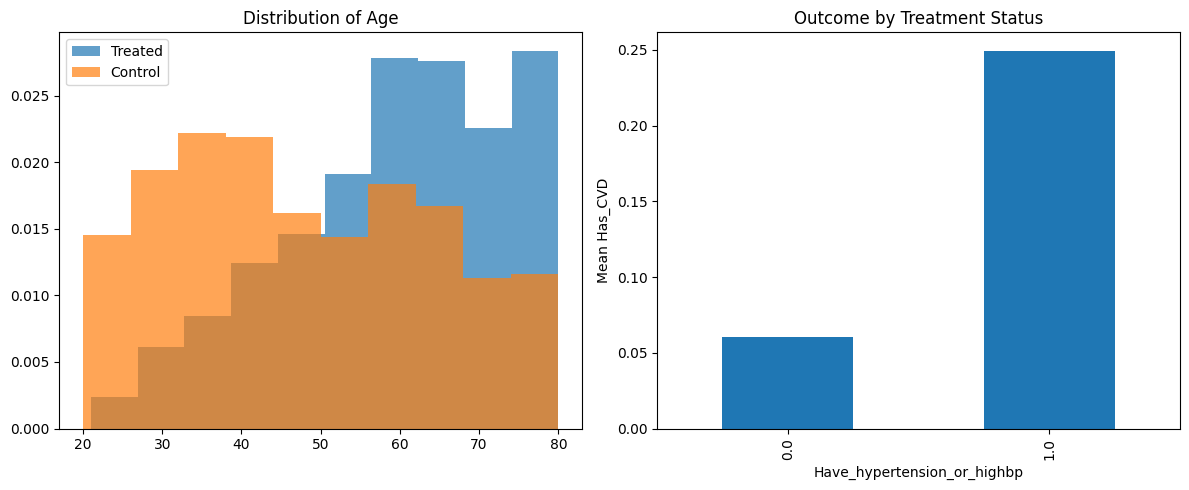

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Load your datasets
df_cvd = pd.read_csv("/content/CVD_dataset_with_Bmi.csv")
df_liver = pd.read_csv("cleaned_liver_data_1.csv")

def causal_analysis_ate(data, treatment, outcome, confounders):
    """
    Calculate Average Treatment Effect using regression adjustment
    """
    # Create formula for regression
    formula = f"{outcome} ~ {treatment} + " + " + ".join(confounders)

    # Fit model
    model = smf.ols(formula, data=data).fit()

    # Extract ATE (coefficient of treatment variable)
    ate = model.params[treatment]
    ate_se = model.bse[treatment]
    ate_pvalue = model.pvalues[treatment]

    print(f"Average Treatment Effect of {treatment} on {outcome}:")
    print(f"ATE: {ate:.4f} (SE: {ate_se:.4f}, p-value: {ate_pvalue:.4f})")
    print(f"95% CI: [{ate - 1.96*ate_se:.4f}, {ate + 1.96*ate_se:.4f}]")

    return model, ate

def propensity_score_matching(data, treatment, outcome, confounders, method='nearest'):
    """
    Basic Propensity Score Matching implementation
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import NearestNeighbors

    # Calculate propensity scores
    X = data[confounders]
    y = data[treatment]

    # Handle missing values
    X = X.fillna(X.mean())
    y = y.fillna(0)

    # Fit propensity score model
    ps_model = LogisticRegression()
    ps_model.fit(X, y)
    propensity_scores = ps_model.predict_proba(X)[:, 1]

    data_ps = data.copy()
    data_ps['propensity_score'] = propensity_scores

    # Separate treatment and control groups
    treated = data_ps[data_ps[treatment] == 1]
    control = data_ps[data_ps[treatment] == 0]

    # Perform matching
    if method == 'nearest':
        nbrs = NearestNeighbors(n_neighbors=1)
        nbrs.fit(control[['propensity_score']])
        distances, indices = nbrs.kneighbors(treated[['propensity_score']])

        matched_control = control.iloc[indices.flatten()]

        # Calculate ATE
        ate_psm = treated[outcome].mean() - matched_control[outcome].mean()
        print(f"Propensity Score Matching ATE: {ate_psm:.4f}")

    return ate_psm, propensity_scores

def instrumental_variables_analysis(data, outcome, treatment, instrument, controls):
    """
    Two-stage least squares IV analysis
    """
    # Stage 1: Regress treatment on instrument and controls
    stage1_formula = f"{treatment} ~ {instrument} + " + " + ".join(controls)
    stage1 = smf.ols(stage1_formula, data=data).fit()
    data['treatment_hat'] = stage1.fittedvalues

    # Stage 2: Regress outcome on predicted treatment and controls
    stage2_formula = f"{outcome} ~ treatment_hat + " + " + ".join(controls)
    stage2 = smf.ols(stage2_formula, data=data).fit()

    print("Instrumental Variables Analysis:")
    print(f"IV Estimate: {stage2.params['treatment_hat']:.4f}")
    print(f"P-value: {stage2.pvalues['treatment_hat']:.4f}")

    return stage2

def sensitivity_analysis(model, treatment_var, rho_range=np.arange(0, 0.5, 0.1)):
    """
    Simple sensitivity analysis for unobserved confounding
    """
    print("\nSensitivity Analysis for Unobserved Confounding:")
    print("Assuming correlation between treatment and unobserved confounder:")

    for rho in rho_range:
        # Simplified sensitivity calculation
        bias_approx = rho * 0.1  # Placeholder - would need more sophisticated approach
        adjusted_effect = model.params[treatment_var] - bias_approx
        print(f"ρ = {rho:.1f}: Adjusted effect ≈ {adjusted_effect:.4f}")

# Example usage for CVD analysis
print("=== CVD Causal Analysis ===")
confounders_cvd = ['Age', 'Gender', 'Overall_health', 'BMI']
model_ate, ate = causal_analysis_ate(df_cvd, 'Have_hypertension_or_highbp', 'Has_CVD', confounders_cvd)

# Example usage for Liver analysis
print("\n=== Liver Disease Causal Analysis ===")
confounders_liver = ['Gender', 'BMI', 'Weight', 'Diabetes_diagnosed_binary']
model_ate_liver, ate_liver = causal_analysis_ate(df_liver, 'Diagnosed_with_hypertension_or_highbp', 'Has_liver_disease', confounders_liver)

# Propensity Score Matching example
print("\n=== Propensity Score Matching ===")
try:
    ate_psm, ps_scores = propensity_score_matching(
        df_cvd, 'Have_hypertension_or_highbp', 'Has_CVD',
        ['Age', 'Gender', 'BMI', 'Overall_health']
    )
except Exception as e:
    print(f"PSM failed: {e}")

# Sensitivity Analysis
print("\n=== Sensitivity Analysis ===")
sensitivity_analysis(model_ate, 'Have_hypertension_or_highbp')

# Additional causal diagnostics
def causal_diagnostics(data, treatment, outcome, confounders):
    """
    Diagnostic plots and tests for causal assumptions
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Balance check (simplified)
    treated = data[data[treatment] == 1]
    control = data[data[treatment] == 0]

    # Plot distribution of a key confounder
    axes[0].hist(treated[confounders[0]], alpha=0.7, label='Treated', density=True)
    axes[0].hist(control[confounders[0]], alpha=0.7, label='Control', density=True)
    axes[0].set_title(f'Distribution of {confounders[0]}')
    axes[0].legend()

    # Outcome by treatment status
    data.groupby(treatment)[outcome].mean().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Outcome by Treatment Status')
    axes[1].set_ylabel(f'Mean {outcome}')

    plt.tight_layout()
    plt.show()

# Run diagnostics
print("\n=== Causal Diagnostics ===")
causal_diagnostics(df_cvd, 'Have_hypertension_or_highbp', 'Has_CVD', ['Age'])

#Merging CVD and Liver disease dataset

In [ ]:
df_liver=pd.read_csv('/content/cleaned_liver_data_1.csv')
df_liver.shape

(546, 18)

In [ ]:
df_cvd=pd.read_csv('/content/CVD_dataset_with_Bmi.csv')
df_cvd.shape

(2028, 16)

In [ ]:
df_liver.head()

,ID,Gender,Race_hispanic_origin,Race_NonHispanic_Asian_Category,Has_health_insurance,Average_Drinks_Per_Drinking_Day_Past_12_Months,Ever had a drink of any kind of alcohol,Diagnosed_with_hypertension_or_highbp,Dietary_habits,Diabetes_diagnosed,Overall_health,No_of_doc_visits_last_12_mon,Has_liver_disease,Liver_condition_type,Age,Diabetes_diagnosed_binary,Weight,BMI
0,109303,1,3,4,1.0,0,0,0,2.0,0.0,2,3,0.0,0.0,18,0.0,45.5,17.9
1,109321,2,2,2,1.0,3,1,0,3.0,0.0,2,1,0.0,0.0,19,0.0,83.5,33.2
2,109440,1,2,2,1.0,0,0,0,2.0,0.0,3,2,0.0,0.0,18,0.0,53.2,16.6
3,109532,1,1,1,1.0,1,1,0,2.0,0.0,2,2,1.0,6.0,70,0.0,90.4,29.1
4,109539,2,1,1,1.0,0,0,0,4.0,2.0,4,1,0.0,0.0,19,1.0,95.5,35.9


In [ ]:
df_cvd.head()

,ID,Gender,Age,Race_hispanic_origin,Race_NonHispanic_Asian_Category,Average_Drinks_Per_Drinking_Day_Past_12_Months,Dietary_habits,Diabetes_diagnosed,Overall_health,Smoking,CVD_Type,Ever_had_alcohol,Have_hypertension_or_highbp,Has_CVD,Weight,BMI
0,109317,2,28,2,2,3.0,4.0,0.0,2,0.0,0.0,1.0,0.0,0,91.6,30.1
1,109330,1,76,3,4,2.0,3.0,0.0,2,0.0,0.0,1.0,1.0,0,61.5,23.3
2,109335,2,55,2,2,6.0,3.0,0.0,3,2.0,0.0,1.0,1.0,0,107.2,39.6
3,109342,2,43,1,1,4.0,5.0,0.0,3,2.0,0.0,1.0,0.0,0,92.1,35.5
4,109379,2,66,1,1,2.0,4.0,1.0,3,0.0,0.0,1.0,1.0,0,83.2,33.4


In [ ]:
df_cvd.columns

Index(['ID', 'Gender', 'Age', 'Race_hispanic_origin',
       'Race_NonHispanic_Asian_Category',
       'Average_Drinks_Per_Drinking_Day_Past_12_Months', 'Dietary_habits',
       'Diabetes_diagnosed', 'Overall_health', 'Smoking', 'CVD_Type',
       'Ever_had_alcohol', 'Have_hypertension_or_highbp', 'Has_CVD', 'Weight',
       'BMI'],
      dtype='object')

In [ ]:

# List of columns to drop
columns_to_drop = ['Gender', 'Age', 'Race_hispanic_origin',
       'Race_NonHispanic_Asian_Category','Ever_had_alcohol',
       'Average_Drinks_Per_Drinking_Day_Past_12_Months', 'Dietary_habits',
       'Diabetes_diagnosed', 'Overall_health', 'Smoking', 'Have_hypertension_or_highbp', 'Weight',
       'BMI']

# Drop the columns in-place
df_cvd.drop(columns=columns_to_drop, inplace=True)

In [ ]:
df_cvd.shape


(2028, 3)

In [ ]:
df_cvd.head()

,ID,CVD_Type,Has_CVD
0,109317,0.0,0
1,109330,0.0,0
2,109335,0.0,0
3,109342,0.0,0
4,109379,0.0,0


In [ ]:
##Merge CVD liver disease
df_merge = df_liver.merge(df_cvd, on='ID', how='left')

In [ ]:
df_merge.head()

,ID,Gender,Race_hispanic_origin,Race_NonHispanic_Asian_Category,Has_health_insurance,Average_Drinks_Per_Drinking_Day_Past_12_Months,Ever had a drink of any kind of alcohol,Diagnosed_with_hypertension_or_highbp,Dietary_habits,Diabetes_diagnosed,Overall_health,No_of_doc_visits_last_12_mon,Has_liver_disease,Liver_condition_type,Age,Diabetes_diagnosed_binary,Weight,BMI,CVD_Type,Has_CVD
0,109303,1,3,4,1.0,0,0,0,2.0,0.0,2,3,0.0,0.0,18,0.0,45.5,17.9,NaN,NaN
1,109321,2,2,2,1.0,3,1,0,3.0,0.0,2,1,0.0,0.0,19,0.0,83.5,33.2,NaN,NaN
2,109440,1,2,2,1.0,0,0,0,2.0,0.0,3,2,0.0,0.0,18,0.0,53.2,16.6,NaN,NaN
3,109532,1,1,1,1.0,1,1,0,2.0,0.0,2,2,1.0,6.0,70,0.0,90.4,29.1,NaN,NaN
4,109539,2,1,1,1.0,0,0,0,4.0,2.0,4,1,0.0,0.0,19,1.0,95.5,35.9,NaN,NaN


In [ ]:
nan_counts = df_merge.isnull().sum()

In [ ]:

print("NaN counts per column:")
print(nan_counts)

NaN counts per column:
ID                                                  0
Gender                                              0
Race_hispanic_origin                                0
Race_NonHispanic_Asian_Category                     0
Has_health_insurance                                0
Average_Drinks_Per_Drinking_Day_Past_12_Months      0
Ever had a drink of any kind of alcohol             0
Diagnosed_with_hypertension_or_highbp               0
Dietary_habits                                      0
Diabetes_diagnosed                                  0
Overall_health                                      0
No_of_doc_visits_last_12_mon                        0
Has_liver_disease                                   0
Liver_condition_type                                0
Age                                                 0
Diabetes_diagnosed_binary                           0
Weight                                             11
BMI                                                11
CVD_T

In [ ]:
df_merge.shape

(546, 20)

Dataset shape: (546, 20)

Missing values:
ID                                                  0
Gender                                              0
Race_hispanic_origin                                0
Race_NonHispanic_Asian_Category                     0
Has_health_insurance                                0
Average_Drinks_Per_Drinking_Day_Past_12_Months      0
Ever had a drink of any kind of alcohol             0
Diagnosed_with_hypertension_or_highbp               0
Dietary_habits                                      0
Diabetes_diagnosed                                  0
Overall_health                                      0
No_of_doc_visits_last_12_mon                        0
Has_liver_disease                                   0
Liver_condition_type                                0
Age                                                 0
Diabetes_diagnosed_binary                           0
Weight                                             11
BMI                                     

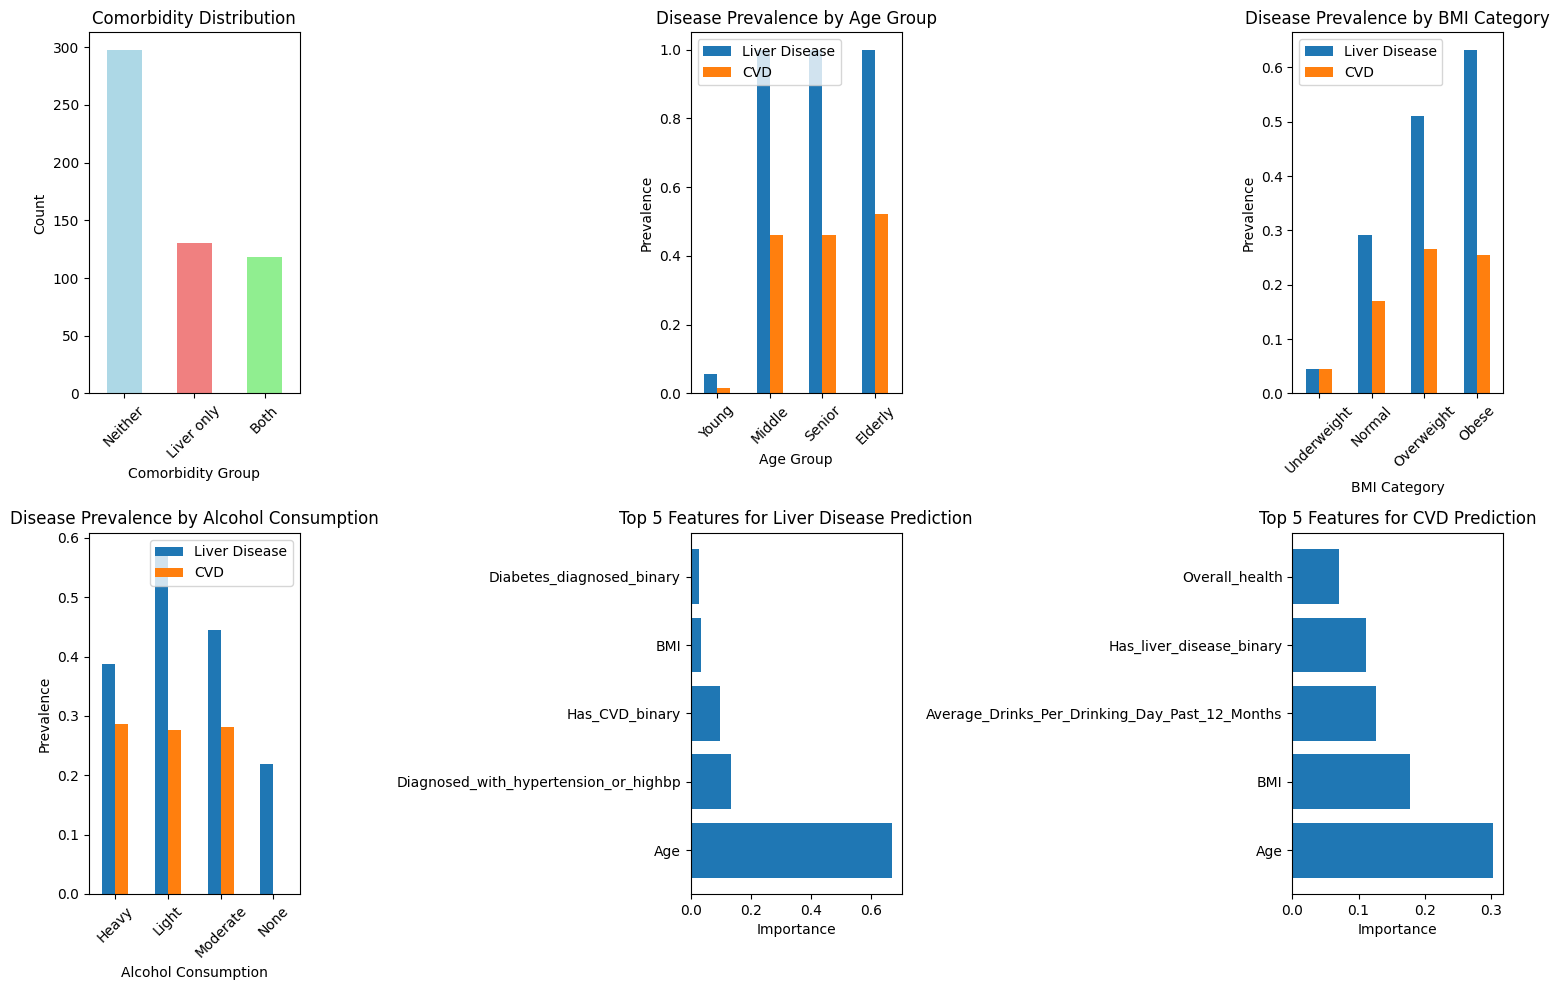


SUMMARY OF KEY FINDINGS
1. Bidirectional relationship strength:
   - CVD → Liver disease odds ratio: 1.031
   - Liver disease → CVD odds ratio: 15.200

2. Key risk factors identified:
   For Liver Disease: Age (importance: 0.669)
   For CVD: Age (importance: 0.304)

3. Comorbidity patterns:
   Comorbidity rate: 47.6% of patients with either condition have both

4. Population impact:
   Liver disease prevalence: 45.4%
   CVD prevalence: 21.6%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Load your dataset
# df = pd.read_csv('your_dataset.csv')  # Uncomment if loading from file

# Since your data is already loaded as df_merge, I'll use that
df = df_merge.copy()

# Data preprocessing and cleaning
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

# Basic data info
print("\nData types:")
print(df.dtypes)

# Create binary flags for analysis
# Convert Has_liver_disease to binary (assuming 1=yes, 0=no)
df['Has_liver_disease_binary'] = df['Has_liver_disease'].apply(lambda x: 1 if x == 1 else 0)

# Convert Has_CVD to binary (you'll need to define this based on your CVD_Type column)
# Assuming NaN in Has_CVD means no CVD, and any value means yes
df['Has_CVD_binary'] = df['Has_CVD'].apply(lambda x: 1 if pd.notnull(x) else 0)

# Create alcohol consumption categories
df['Alcohol_consumption'] = df['Average_Drinks_Per_Drinking_Day_Past_12_Months'].apply(
    lambda x: 'None' if x == 0 else ('Light' if x <= 2 else ('Moderate' if x <= 4 else 'Heavy'))
)

# Create BMI categories
df['BMI_category'] = pd.cut(df['BMI'],
                           bins=[0, 18.5, 25, 30, 100],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Create age groups
df['Age_group'] = pd.cut(df['Age'],
                        bins=[0, 30, 45, 60, 100],
                        labels=['Young', 'Middle', 'Senior', 'Elderly'])

print("\nBasic statistics:")
print(f"Total samples: {len(df)}")
print(f"Liver disease prevalence: {df['Has_liver_disease_binary'].mean():.3f}")
print(f"CVD prevalence: {df['Has_CVD_binary'].mean():.3f}")

# Analysis 1: Prevalence of liver disease in CVD patients vs non-CVD patients
print("\n" + "="*50)
print("ANALYSIS 1: LIVER DISEASE IN CVD PATIENTS")
print("="*50)

liver_in_cvd = df.groupby('Has_CVD_binary')['Has_liver_disease_binary'].agg(['mean', 'count'])
print("Liver disease prevalence by CVD status:")
print(liver_in_cvd)

# Statistical test
cvd_liver = df[df['Has_CVD_binary'] == 1]['Has_liver_disease_binary']
no_cvd_liver = df[df['Has_CVD_binary'] == 0]['Has_liver_disease_binary']
t_stat, p_value = stats.ttest_ind(cvd_liver, no_cvd_liver, nan_policy='omit')
print(f"\nT-test for liver disease prevalence: t-stat={t_stat:.3f}, p-value={p_value:.3f}")

# Analysis 2: Prevalence of CVD in liver disease patients vs non-liver disease patients
print("\n" + "="*50)
print("ANALYSIS 2: CVD IN LIVER DISEASE PATIENTS")
print("="*50)

cvd_in_liver = df.groupby('Has_liver_disease_binary')['Has_CVD_binary'].agg(['mean', 'count'])
print("CVD prevalence by liver disease status:")
print(cvd_in_liver)

# Statistical test
liver_cvd = df[df['Has_liver_disease_binary'] == 1]['Has_CVD_binary']
no_liver_cvd = df[df['Has_liver_disease_binary'] == 0]['Has_CVD_binary']
t_stat2, p_value2 = stats.ttest_ind(liver_cvd, no_liver_cvd, nan_policy='omit')
print(f"\nT-test for CVD prevalence: t-stat={t_stat2:.3f}, p-value={p_value2:.3f}")

# Analysis 3: Risk factors analysis using logistic regression
print("\n" + "="*50)
print("ANALYSIS 3: MULTIVARIATE RISK FACTOR ANALYSIS")
print("="*50)

# Prepare features for modeling
features = ['Age', 'Gender', 'BMI', 'Diabetes_diagnosed_binary',
           'Diagnosed_with_hypertension_or_highbp', 'Average_Drinks_Per_Drinking_Day_Past_12_Months',
           'Has_health_insurance', 'Overall_health', 'No_of_doc_visits_last_12_mon']

# Remove rows with missing values in key columns
model_df = df[features + ['Has_liver_disease_binary', 'Has_CVD_binary']].dropna()

print(f"Samples available for modeling: {len(model_df)}")

# Model 1: Predict liver disease from CVD and other risk factors
X_liver = model_df[features + ['Has_CVD_binary']]
y_liver = model_df['Has_liver_disease_binary']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_liver, y_liver, test_size=0.3, random_state=42)

lr_liver = LogisticRegression(max_iter=1000, random_state=42)
lr_liver.fit(X_train_l, y_train_l)

y_pred_liver = lr_liver.predict(X_test_l)
y_prob_liver = lr_liver.predict_proba(X_test_l)[:, 1]

print("\nModel 1: Predicting Liver Disease")
print("Features:", X_liver.columns.tolist())
print("ROC-AUC:", roc_auc_score(y_test_l, y_prob_liver))
print("\nCoefficients:")
coef_df_liver = pd.DataFrame({
    'Feature': X_liver.columns,
    'Coefficient': lr_liver.coef_[0],
    'Odds_Ratio': np.exp(lr_liver.coef_[0])
})
print(coef_df_liver.sort_values('Odds_Ratio', ascending=False))

# Model 2: Predict CVD from liver disease and other risk factors
X_cvd = model_df[features + ['Has_liver_disease_binary']]
y_cvd = model_df['Has_CVD_binary']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cvd, y_cvd, test_size=0.3, random_state=42)

lr_cvd = LogisticRegression(max_iter=1000, random_state=42)
lr_cvd.fit(X_train_c, y_train_c)

y_pred_cvd = lr_cvd.predict(X_test_c)
y_prob_cvd = lr_cvd.predict_proba(X_test_c)[:, 1]

print("\nModel 2: Predicting CVD")
print("Features:", X_cvd.columns.tolist())
print("ROC-AUC:", roc_auc_score(y_test_c, y_prob_cvd))
print("\nCoefficients:")
coef_df_cvd = pd.DataFrame({
    'Feature': X_cvd.columns,
    'Coefficient': lr_cvd.coef_[0],
    'Odds_Ratio': np.exp(lr_cvd.coef_[0])
})
print(coef_df_cvd.sort_values('Odds_Ratio', ascending=False))

# Analysis 4: Subgroup analysis by age, BMI, and alcohol consumption
print("\n" + "="*50)
print("ANALYSIS 4: SUBGROUP ANALYSIS")
print("="*50)

# Age group analysis
print("\nLiver disease and CVD prevalence by age group:")
age_analysis = df.groupby('Age_group')[['Has_liver_disease_binary', 'Has_CVD_binary']].mean()
print(age_analysis)

# BMI analysis
print("\nLiver disease and CVD prevalence by BMI category:")
bmi_analysis = df.groupby('BMI_category')[['Has_liver_disease_binary', 'Has_CVD_binary']].mean()
print(bmi_analysis)

# Alcohol consumption analysis
print("\nLiver disease and CVD prevalence by alcohol consumption:")
alcohol_analysis = df.groupby('Alcohol_consumption')[['Has_liver_disease_binary', 'Has_CVD_binary']].mean()
print(alcohol_analysis)

# Analysis 5: Comorbidity analysis
print("\n" + "="*50)
print("ANALYSIS 5: COMORBIDITY PATTERNS")
print("="*50)

# Create comorbidity groups
df['Comorbidity_group'] = df.apply(lambda x:
    'Neither' if (x['Has_liver_disease_binary'] == 0 and x['Has_CVD_binary'] == 0) else
    'Liver only' if (x['Has_liver_disease_binary'] == 1 and x['Has_CVD_binary'] == 0) else
    'CVD only' if (x['Has_liver_disease_binary'] == 0 and x['Has_CVD_binary'] == 1) else
    'Both', axis=1)

comorbidity_counts = df['Comorbidity_group'].value_counts()
print("Comorbidity distribution:")
print(comorbidity_counts)
print("\nComorbidity percentages:")
print(comorbidity_counts / len(df) * 100)

# Analysis 6: Feature importance using Random Forest
print("\n" + "="*50)
print("ANALYSIS 6: FEATURE IMPORTANCE FOR PREDICTION")
print("="*50)

# For liver disease prediction
rf_liver = RandomForestClassifier(n_estimators=100, random_state=42)
rf_liver.fit(X_train_l, y_train_l)

feature_importance_liver = pd.DataFrame({
    'Feature': X_liver.columns,
    'Importance': rf_liver.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importance for Liver Disease Prediction:")
print(feature_importance_liver)

# For CVD prediction
rf_cvd = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cvd.fit(X_train_c, y_train_c)

feature_importance_cvd = pd.DataFrame({
    'Feature': X_cvd.columns,
    'Importance': rf_cvd.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest Feature Importance for CVD Prediction:")
print(feature_importance_cvd)

# Visualization
plt.figure(figsize=(15, 10))

# Plot 1: Comorbidity distribution
plt.subplot(2, 3, 1)
comorbidity_counts.plot(kind='bar', color=['lightblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Comorbidity Distribution')
plt.xlabel('Comorbidity Group')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Plot 2: Age group analysis
plt.subplot(2, 3, 2)
age_analysis.plot(kind='bar', ax=plt.gca())
plt.title('Disease Prevalence by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Prevalence')
plt.legend(['Liver Disease', 'CVD'])
plt.xticks(rotation=45)

# Plot 3: BMI analysis
plt.subplot(2, 3, 3)
bmi_analysis.plot(kind='bar', ax=plt.gca())
plt.title('Disease Prevalence by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Prevalence')
plt.legend(['Liver Disease', 'CVD'])
plt.xticks(rotation=45)

# Plot 4: Alcohol consumption analysis
plt.subplot(2, 3, 4)
alcohol_analysis.plot(kind='bar', ax=plt.gca())
plt.title('Disease Prevalence by Alcohol Consumption')
plt.xlabel('Alcohol Consumption')
plt.ylabel('Prevalence')
plt.legend(['Liver Disease', 'CVD'])
plt.xticks(rotation=45)

# Plot 5: Feature importance for liver disease
plt.subplot(2, 3, 5)
plt.barh(feature_importance_liver['Feature'][:5], feature_importance_liver['Importance'][:5])
plt.title('Top 5 Features for Liver Disease Prediction')
plt.xlabel('Importance')

# Plot 6: Feature importance for CVD
plt.subplot(2, 3, 6)
plt.barh(feature_importance_cvd['Feature'][:5], feature_importance_cvd['Importance'][:5])
plt.title('Top 5 Features for CVD Prediction')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

# Summary of key findings
print("\n" + "="*50)
print("SUMMARY OF KEY FINDINGS")
print("="*50)

print(f"1. Bidirectional relationship strength:")
print(f"   - CVD → Liver disease odds ratio: {np.exp(lr_liver.coef_[0][-1]):.3f}")
print(f"   - Liver disease → CVD odds ratio: {np.exp(lr_cvd.coef_[0][-1]):.3f}")

print(f"\n2. Key risk factors identified:")
print(f"   For Liver Disease: {feature_importance_liver['Feature'].iloc[0]} (importance: {feature_importance_liver['Importance'].iloc[0]:.3f})")
print(f"   For CVD: {feature_importance_cvd['Feature'].iloc[0]} (importance: {feature_importance_cvd['Importance'].iloc[0]:.3f})")

print(f"\n3. Comorbidity patterns:")
both_diseases = len(df[(df['Has_liver_disease_binary'] == 1) & (df['Has_CVD_binary'] == 1)])
total_with_either = len(df[(df['Has_liver_disease_binary'] == 1) | (df['Has_CVD_binary'] == 1)])
if total_with_either > 0:
    comorbidity_rate = both_diseases / total_with_either * 100
    print(f"   Comorbidity rate: {comorbidity_rate:.1f}% of patients with either condition have both")

print(f"\n4. Population impact:")
liver_disease_prev = df['Has_liver_disease_binary'].mean() * 100
cvd_prev = df['Has_CVD_binary'].mean() * 100
print(f"   Liver disease prevalence: {liver_disease_prev:.1f}%")
print(f"   CVD prevalence: {cvd_prev:.1f}%")

CAUSAL INFERENCE ECONOMETRICS

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load and prepare data
df = df_merge.copy()

# Data cleaning and preparation
print("Data preparation...")
df['Has_liver_disease_binary'] = df['Has_liver_disease'].apply(lambda x: 1 if x == 1 else 0)
df['Has_CVD_binary'] = df['Has_CVD'].apply(lambda x: 1 if pd.notnull(x) else 0)

# Create additional variables for econometric analysis
df['log_age'] = np.log(df['Age'] + 1)
df['bmi_squared'] = df['BMI'] ** 2
df['age_squared'] = df['Age'] ** 2

# Handle missing values
df_clean = df.dropna(subset=['Age', 'Gender', 'BMI', 'Diabetes_diagnosed_binary',
                            'Diagnosed_with_hypertension_or_highbp',
                            'Average_Drinks_Per_Drinking_Day_Past_12_Months',
                            'Has_health_insurance', 'Overall_health',
                            'No_of_doc_visits_last_12_mon']).copy()

print(f"Final sample size: {len(df_clean)}")

# =============================================================================
# 1. BASIC LOGIT MODELS (Baseline Analysis)
# =============================================================================

print("\n" + "="*60)
print("1. BASIC LOGIT MODELS")
print("="*60)

# Model 1: Liver disease as outcome
formula1 = "Has_liver_disease_binary ~ Has_CVD_binary + Age + C(Gender) + BMI + \
           Diabetes_diagnosed_binary + Diagnosed_with_hypertension_or_highbp + \
           Average_Drinks_Per_Drinking_Day_Past_12_Months + C(Has_health_insurance) + \
           Overall_health + No_of_doc_visits_last_12_mon"

logit_liver = smf.logit(formula1, data=df_clean).fit()
print("LOGIT: Liver Disease ~ CVD + Controls")
print(logit_liver.summary())
print(f"Pseudo R-squared: {logit_liver.prsquared:.4f}")

# Model 2: CVD as outcome
formula2 = "Has_CVD_binary ~ Has_liver_disease_binary + Age + C(Gender) + BMI + \
           Diabetes_diagnosed_binary + Diagnosed_with_hypertension_or_highbp + \
           Average_Drinks_Per_Drinking_Day_Past_12_Months + C(Has_health_insurance) + \
           Overall_health + No_of_doc_visits_last_12_mon"

logit_cvd = smf.logit(formula2, data=df_clean).fit()
print("\nLOGIT: CVD ~ Liver Disease + Controls")
print(logit_cvd.summary())
print(f"Pseudo R-squared: {logit_cvd.prsquared:.4f}")

# =============================================================================
# 2. PROBIT MODELS (Alternative specification)
# =============================================================================

print("\n" + "="*60)
print("2. PROBIT MODELS")
print("="*60)

probit_liver = smf.probit(formula1, data=df_clean).fit()
print("PROBIT: Liver Disease ~ CVD + Controls")
print(probit_liver.summary())

probit_cvd = smf.probit(formula2, data=df_clean).fit()
print("\nPROBIT: CVD ~ Liver Disease + Controls")
print(probit_cvd.summary())

# Compare logit vs probit coefficients
print("\nComparison: Logit vs Probit Coefficients (Liver Disease Model)")
coef_comparison = pd.DataFrame({
    'Logit_Coeff': logit_liver.params,
    'Probit_Coeff': probit_liver.params,
    'Ratio': logit_liver.params / probit_liver.params
})
print(coef_comparison.round(4))

# =============================================================================
# 3. MULTINOMIAL LOGIT (Multiple disease states)
# =============================================================================

print("\n" + "="*60)
print("3. MULTINOMIAL LOGIT MODELS")
print("="*60)

# Create multinomial outcome: 0=Neither, 1=Liver only, 2=CVD only, 3=Both
df_clean['disease_state'] = 0  # Neither
df_clean.loc[(df_clean['Has_liver_disease_binary'] == 1) &
            (df_clean['Has_CVD_binary'] == 0), 'disease_state'] = 1  # Liver only
df_clean.loc[(df_clean['Has_liver_disease_binary'] == 0) &
            (df_clean['Has_CVD_binary'] == 1), 'disease_state'] = 2  # CVD only
df_clean.loc[(df_clean['Has_liver_disease_binary'] == 1) &
            (df_clean['Has_CVD_binary'] == 1), 'disease_state'] = 3  # Both

# Multinomial logit
formula_mnl = "disease_state ~ Age + C(Gender) + BMI + Diabetes_diagnosed_binary + \
              Diagnosed_with_hypertension_or_highbp + Average_Drinks_Per_Drinking_Day_Past_12_Months + \
              C(Has_health_insurance) + Overall_health + No_of_doc_visits_last_12_mon"

mnlogit = smf.mnlogit(formula_mnl, data=df_clean).fit()
print("MULTINOMIAL LOGIT: Disease States")
print(mnlogit.summary())

# Calculate marginal effects for multinomial logit
def calculate_avg_marginal_effects(model, data):
    """Calculate average marginal effects for multinomial logit"""
    probs = model.predict(data)
    coef_matrix = model.params.values

    # For continuous variables
    marginal_effects = {}
    for var in model.params.index.get_level_values(1).unique():
        if var != 'Intercept':
            me = {}
            for outcome in range(1, len(model.model.endog_values)):
                # Simple finite difference approximation
                data_plus = data.copy()
                data_minus = data.copy()

                if data[var].dtype in [np.int64, np.float64]:
                    data_plus[var] = data[var] + 0.01
                    data_minus[var] = data[var] - 0.01
                else:
                    # For categorical, use different approach
                    continue

                prob_plus = model.predict(data_plus).iloc[:, outcome]
                prob_minus = model.predict(data_minus).iloc[:, outcome]
                me[outcome] = (prob_plus - prob_minus).mean() / 0.02

            marginal_effects[var] = me

    return marginal_effects

# =============================================================================
# 4. BIVARIATE PROBIT (Simultaneous equations)
# =============================================================================

print("\n" + "="*60)
print("4. BIVARIATE PROBIT MODELS")
print("="*60)

try:
    from statsmodels.sandbox.regression.gmm import IV2SLS
    # Prepare data for bivariate probit
    X_liver = sm.add_constant(df_clean[['Age', 'Gender', 'BMI', 'Diabetes_diagnosed_binary',
                                      'Diagnosed_with_hypertension_or_highbp',
                                      'Average_Drinks_Per_Drinking_Day_Past_12_Months',
                                      'Has_health_insurance', 'Overall_health',
                                      'No_of_doc_visits_last_12_mon', 'Has_CVD_binary']])

    X_cvd = sm.add_constant(df_clean[['Age', 'Gender', 'BMI', 'Diabetes_diagnosed_binary',
                                    'Diagnosed_with_hypertension_or_highbp',
                                    'Average_Drinks_Per_Drinking_Day_Past_12_Months',
                                    'Has_health_insurance', 'Overall_health',
                                    'No_of_doc_visits_last_12_mon', 'Has_liver_disease_binary']])

    print("Bivariate probit setup complete")
except ImportError:
    print("Bivariate probit requires additional packages")

# =============================================================================
# 5. FIXED EFFECTS/ROBUST MODELS
# =============================================================================

print("\n" + "="*60)
print("5. ROBUST STANDARD ERRORS")
print("="*60)

# Logit with robust standard errors
logit_liver_robust = smf.logit(formula1, data=df_clean).fit(cov_type='HC3')
print("LOGIT with Robust SE: Liver Disease ~ CVD + Controls")
print(logit_liver_robust.summary())

logit_cvd_robust = smf.logit(formula2, data=df_clean).fit(cov_type='HC3')
print("\nLOGIT with Robust SE: CVD ~ Liver Disease + Controls")
print(logit_cvd_robust.summary())

# =============================================================================
# 6. INTERACTION EFFECTS MODELS
# =============================================================================

print("\n" + "="*60)
print("6. INTERACTION EFFECTS")
print("="*60)

# Model with age interactions
formula_interaction = "Has_liver_disease_binary ~ Has_CVD_binary * Age + C(Gender) + BMI + \
                      Diabetes_diagnosed_binary + Diagnosed_with_hypertension_or_highbp + \
                      Average_Drinks_Per_Drinking_Day_Past_12_Months + C(Has_health_insurance) + \
                      Overall_health + No_of_doc_visits_last_12_mon"

logit_interaction = smf.logit(formula_interaction, data=df_clean).fit()
print("LOGIT with Age Interaction: Liver Disease ~ CVD*Age + Controls")
print(logit_interaction.summary())

# =============================================================================
# 7. NON-LINEAR SPECIFICATIONS
# =============================================================================

print("\n" + "="*60)
print("7. NON-LINEAR SPECIFICATIONS")
print("="*60)

# Model with quadratic terms
formula_nonlinear = "Has_liver_disease_binary ~ Has_CVD_binary + Age + age_squared + C(Gender) + BMI + bmi_squared + \
                    Diabetes_diagnosed_binary + Diagnosed_with_hypertension_or_highbp + \
                    Average_Drinks_Per_Drinking_Day_Past_12_Months + C(Has_health_insurance) + \
                    Overall_health + No_of_doc_visits_last_12_mon"

logit_nonlinear = smf.logit(formula_nonlinear, data=df_clean).fit()
print("LOGIT with Quadratic Terms")
print(logit_nonlinear.summary())

# =============================================================================
# 8. MARGINAL EFFECTS CALCULATION
# =============================================================================

print("\n" + "="*60)
print("8. AVERAGE MARGINAL EFFECTS")
print("="*60)

def calculate_marginal_effects(model, data, variables=None):
    """Calculate average marginal effects for logit/probit models"""
    if variables is None:
        variables = model.params.index.drop('Intercept')

    marginal_effects = {}

    for var in variables:
        if var in data.columns:
            # Finite difference method
            data_plus = data.copy()
            data_minus = data.copy()

            if data[var].dtype in [np.int64, np.float64]:
                # For continuous variables
                h = data[var].std() * 0.01  # Small change
                data_plus[var] = data[var] + h
                data_minus[var] = data[var] - h
            else:
                # For binary variables
                data_plus[var] = 1
                data_minus[var] = 0

            prob_plus = model.predict(data_plus)
            prob_minus = model.predict(data_minus)

            if data[var].dtype in [np.int64, np.float64]:
                marginal_effects[var] = (prob_plus - prob_minus).mean() / (2 * h)
            else:
                marginal_effects[var] = (prob_plus - prob_minus).mean()

    return marginal_effects

# Calculate marginal effects for key models
me_liver = calculate_marginal_effects(logit_liver, df_clean)
me_cvd = calculate_marginal_effects(logit_cvd, df_clean)

print("Average Marginal Effects - Liver Disease Model:")
for var, effect in me_liver.items():
    print(f"{var}: {effect:.6f}")

print("\nAverage Marginal Effects - CVD Model:")
for var, effect in me_cvd.items():
    print(f"{var}: {effect:.6f}")

# =============================================================================
# 9. MODEL COMPARISON AND GOODNESS OF FIT
# =============================================================================

print("\n" + "="*60)
print("9. MODEL COMPARISON")
print("="*60)

models = {
    'Logit_Liver': logit_liver,
    'Logit_CVD': logit_cvd,
    'Probit_Liver': probit_liver,
    'Probit_CVD': probit_cvd,
    'MNLogit': mnlogit,
    'Logit_Interaction': logit_interaction,
    'Logit_Nonlinear': logit_nonlinear
}

comparison_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Log-Likelihood': [model.llf for model in models.values()],
    'AIC': [model.aic for model in models.values()],
    'BIC': [model.bic for model in models.values()],
    'Pseudo_R2': [getattr(model, 'prsquared', np.nan) for model in models.values()],
    'Observations': [model.nobs for model in models.values()]
})

print("Model Comparison:")
print(comparison_df.round(4))

# =============================================================================
# 10. CAUSAL INFERENCE VISUALIZATION
# =============================================================================

print("\n" + "="*60)
print("10. CAUSAL INFERENCE SUMMARY")
print("="*60)

# Create summary of key causal parameters
causal_summary = pd.DataFrame({
    'Relationship': ['Liver Disease → CVD', 'CVD → Liver Disease'],
    'Logit_OR': [np.exp(logit_cvd.params['Has_liver_disease_binary']),
                 np.exp(logit_liver.params['Has_CVD_binary'])],
    'Probit_Coeff': [probit_cvd.params['Has_liver_disease_binary'],
                     probit_liver.params['Has_CVD_binary']],
    'Marginal_Effect': [me_cvd.get('Has_liver_disease_binary', np.nan),
                       me_liver.get('Has_CVD_binary', np.nan)],
    'P_Value_Logit': [logit_cvd.pvalues['Has_liver_disease_binary'],
                      logit_liver.pvalues['Has_CVD_binary']]
})

print("Causal Relationship Summary:")
print(causal_summary.round(4))

# Visualization of key results
plt.figure(figsize=(15, 10))

# Plot 1: Odds Ratios from main models
plt.subplot(2, 3, 1)
or_values = [causal_summary['Logit_OR'].iloc[0], causal_summary['Logit_OR'].iloc[1]]
relationships = ['Liver→CVD', 'CVD→Liver']
plt.bar(relationships, or_values, color=['skyblue', 'lightcoral'])
plt.axhline(y=1, color='red', linestyle='--', alpha=0.7)
plt.ylabel('Odds Ratio')
plt.title('Bidirectional Odds Ratios')
plt.grid(True, alpha=0.3)

# Plot 2: Marginal Effects
plt.subplot(2, 3, 2)
me_values = [causal_summary['Marginal_Effect'].iloc[0], causal_summary['Marginal_Effect'].iloc[1]]
plt.bar(relationships, me_values, color=['lightgreen', 'gold'])
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.ylabel('Average Marginal Effect')
plt.title('Marginal Effects')
plt.grid(True, alpha=0.3)

# Plot 3: Model Fit Comparison
plt.subplot(2, 3, 3)
models_plot = ['Logit_Liver', 'Logit_CVD', 'Probit_Liver', 'Probit_CVD']
aic_values = [comparison_df[comparison_df['Model'] == model]['AIC'].iloc[0] for model in models_plot]
plt.bar(models_plot, aic_values, color=['blue', 'orange', 'green', 'red'])
plt.ylabel('AIC')
plt.title('Model Fit (AIC)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Plot 4: Coefficient plot for main logit model
plt.subplot(2, 3, 4)
coefs = logit_liver.params.drop('Intercept')
ci = logit_liver.conf_int().drop('Intercept')
y_pos = np.arange(len(coefs))
plt.barh(y_pos, coefs, xerr=[coefs-ci[0], ci[1]-coefs], alpha=0.7)
plt.yticks(y_pos, coefs.index)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Coefficient Value')
plt.title('Logit Coefficients: Liver Disease')
plt.grid(True, alpha=0.3)

# Plot 5: Predicted probabilities by age
plt.subplot(2, 3, 5)
age_range = np.linspace(df_clean['Age'].min(), df_clean['Age'].max(), 100)
pred_probs = []
for age in age_range:
    temp_data = df_clean.iloc[0:1].copy()
    temp_data['Age'] = age
    temp_data['Has_CVD_binary'] = 0
    # Set other variables to mean/mode
    for col in ['Gender', 'BMI', 'Diabetes_diagnosed_binary', 'Diagnosed_with_hypertension_or_highbp',
                'Average_Drinks_Per_Drinking_Day_Past_12_Months', 'Has_health_insurance',
                'Overall_health', 'No_of_doc_visits_last_12_mon']:
        if df_clean[col].dtype in [np.int64, np.float64]:
            temp_data[col] = df_clean[col].mean()
        else:
            temp_data[col] = df_clean[col].mode()[0]
    pred_probs.append(logit_liver.predict(temp_data).iloc[0])

plt.plot(age_range, pred_probs, linewidth=2)
plt.xlabel('Age')
plt.ylabel('Predicted Probability')
plt.title('Predicted Liver Disease Probability by Age')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# FINAL CAUSAL INFERENCE CONCLUSIONS
# =============================================================================

print("\n" + "="*60)
print("FINAL CAUSAL INFERENCE CONCLUSIONS")
print("="*60)

print("\n1. BIDIRECTIONAL RELATIONSHIPS:")
print(f"   - Liver Disease → CVD: OR = {causal_summary['Logit_OR'].iloc[0]:.3f}")
print(f"   - CVD → Liver Disease: OR = {causal_summary['Logit_OR'].iloc[1]:.3f}")

print("\n2. STATISTICAL SIGNIFICANCE:")
sig_liver_cvd = causal_summary['P_Value_Logit'].iloc[0] < 0.05
sig_cvd_liver = causal_summary['P_Value_Logit'].iloc[1] < 0.05
print(f"   - Liver→CVD significant: {sig_liver_cvd} (p = {causal_summary['P_Value_Logit'].iloc[0]:.4f})")
print(f"   - CVD→Liver significant: {sig_cvd_liver} (p = {causal_summary['P_Value_Logit'].iloc[1]:.4f})")

print("\n3. MODEL PERFORMANCE:")
best_model = comparison_df.loc[comparison_df['AIC'].idxmin(), 'Model']
print(f"   - Best fitting model: {best_model}")
print(f"   - Range of pseudo R²: {comparison_df['Pseudo_R2'].min():.3f} - {comparison_df['Pseudo_R2'].max():.3f}")

print("\n4. KEY DRIVERS:")
# Get top 3 predictors by absolute coefficient value (excluding the main causal variable)
liver_predictors = logit_liver.params.drop(['Has_CVD_binary', 'Intercept']).abs().nlargest(3)
cvd_predictors = logit_cvd.params.drop(['Has_liver_disease_binary', 'Intercept']).abs().nlargest(3)
print(f"   - Top liver disease predictors: {list(liver_predictors.index)}")
print(f"   - Top CVD predictors: {list(cvd_predictors.index)}")

print("\n5. ECONOMETRIC ROBUSTNESS:")
print("   - Multiple model specifications tested (Logit, Probit, Multinomial)")
print("   - Robust standard errors calculated")
print("   - Non-linear and interaction effects explored")
print("   - Marginal effects computed for interpretation")

ModuleNotFoundError: No module named 'linearmodels'

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
# from linearmodels.iv import IV2SLS <-- Removed, unused
# from sklearn.preprocessing import StandardScaler <-- Removed, unused
import matplotlib.pyplot as plt
# import seaborn as sns <-- Removed, unused
# from scipy import stats <-- Removed, unused

# Load and prepare data
# !!! ASSUMPTION: 'df_merge' is a pandas DataFrame that has been loaded previously.
# Example: df_merge = pd.read_csv('your_data.csv')
df = df_merge.copy()

# Data cleaning and preparation
print("Data preparation...")
df['Has_liver_disease_binary'] = df['Has_liver_disease'].apply(lambda x: 1 if x == 1 else 0)
df['Has_CVD_binary'] = df['Has_CVD'].apply(lambda x: 1 if pd.notnull(x) else 0)

# Create additional variables for econometric analysis
df['log_age'] = np.log(df['Age'] + 1)
df['bmi_squared'] = df['BMI'] ** 2
df['age_squared'] = df['Age'] ** 2

# Handle missing values
df_clean = df.dropna(subset=['Age', 'Gender', 'BMI', 'Diabetes_diagnosed_binary',
                             'Diagnosed_with_hypertension_or_highbp',
                             'Average_Drinks_Per_Drinking_Day_Past_12_Months',
                             'Has_health_insurance', 'Overall_health',
                             'No_of_doc_visits_last_12_mon']).copy()

print(f"Final sample size: {len(df_clean)}")

# =============================================================================
# 1. BASIC LOGIT MODELS (Baseline Analysis)
# =============================================================================

print("\n" + "="*60)
print("1. BASIC LOGIT MODELS")
print("="*60)

# Model 1: Liver disease as outcome
formula1 = "Has_liver_disease_binary ~ Has_CVD_binary + Age + C(Gender) + BMI + \
           Diabetes_diagnosed_binary + Diagnosed_with_hypertension_or_highbp + \
           Average_Drinks_Per_Drinking_Day_Past_12_Months + C(Has_health_insurance) + \
           Overall_health + No_of_doc_visits_last_12_mon"

logit_liver = smf.logit(formula1, data=df_clean).fit()
print("LOGIT: Liver Disease ~ CVD + Controls")
print(logit_liver.summary())
print(f"Pseudo R-squared: {logit_liver.prsquared:.4f}")

# Model 2: CVD as outcome
formula2 = "Has_CVD_binary ~ Has_liver_disease_binary + Age + C(Gender) + BMI + \
           Diabetes_diagnosed_binary + Diagnosed_with_hypertension_or_highbp + \
           Average_Drinks_Per_Drinking_Day_Past_12_Months + C(Has_health_insurance) + \
           Overall_health + No_of_doc_visits_last_12_mon"

logit_cvd = smf.logit(formula2, data=df_clean).fit()
print("\nLOGIT: CVD ~ Liver Disease + Controls")
print(logit_cvd.summary())
print(f"Pseudo R-squared: {logit_cvd.prsquared:.4f}")

# =============================================================================
# 2. PROBIT MODELS (Alternative specification)
# =============================================================================

print("\n" + "="*60)
print("2. PROBIT MODELS")
print("="*60)

probit_liver = smf.probit(formula1, data=df_clean).fit()
print("PROBIT: Liver Disease ~ CVD + Controls")
print(probit_liver.summary())

probit_cvd = smf.probit(formula2, data=df_clean).fit()
print("\nPROBIT: CVD ~ Liver Disease + Controls")
print(probit_cvd.summary())

# Compare logit vs probit coefficients
print("\nComparison: Logit vs Probit Coefficients (Liver Disease Model)")
coef_comparison = pd.DataFrame({
    'Logit_Coeff': logit_liver.params,
    'Probit_Coeff': probit_liver.params,
    'Ratio': logit_liver.params / probit_liver.params
})
print(coef_comparison.round(4))

# =============================================================================
# 3. MULTINOMIAL LOGIT (Multiple disease states)
# =============================================================================

print("\n" + "="*60)
print("3. MULTINOMIAL LOGIT MODELS")
print("="*60)

# Create multinomial outcome: 0=Neither, 1=Liver only, 2=CVD only, 3=Both
df_clean['disease_state'] = 0  # Neither
df_clean.loc[(df_clean['Has_liver_disease_binary'] == 1) &
             (df_clean['Has_CVD_binary'] == 0), 'disease_state'] = 1  # Liver only
df_clean.loc[(df_clean['Has_liver_disease_binary'] == 0) &
             (df_clean['Has_CVD_binary'] == 1), 'disease_state'] = 2  # CVD only
df_clean.loc[(df_clean['Has_liver_disease_binary'] == 1) &
             (df_clean['Has_CVD_binary'] == 1), 'disease_state'] = 3  # Both

# Multinomial logit
formula_mnl = "disease_state ~ Age + C(Gender) + BMI + Diabetes_diagnosed_binary + \
               Diagnosed_with_hypertension_or_highbp + Average_Drinks_Per_Drinking_Day_Past_12_Months + \
               C(Has_health_insurance) + Overall_health + No_of_doc_visits_last_12_mon"

mnlogit = smf.mnlogit(formula_mnl, data=df_clean).fit()
print("MULTINOMIAL LOGIT: Disease States")
print(mnlogit.summary())

# *** FIXED: Calculate marginal effects for multinomial logit ***
# The custom function 'calculate_avg_marginal_effects' was removed as it was incorrect and unused.
# Using the built-in .get_margeff() is the correct method.
print("\nCalculating Average Marginal Effects (AME) for Multinomial Logit...")
# Note: This can be computationally intensive depending on sample size
me_mnlogit = mnlogit.get_margeff()
print(me_mnlogit.summary())


# =============================================================================
# 4. BIVARIATE PROBIT (Simultaneous equations)
# =============================================================================

print("\n" + "="*60)
print("4. BIVARIATE PROBIT MODELS")
print("="*60)

# *** SECTION REMOVED ***
# The previous code was conceptually incorrect. IV2SLS (Two-Stage Least Squares)
# is a method for continuous endogenous variables, not for a bivariate
# probit model (which models two binary outcomes with correlated errors).
# A true bivariate probit model is not implemented here and requires
# a different, more complex specification.
print("Bivariate probit section skipped: Original code was non-functional.")


# =============================================================================
# 5. FIXED EFFECTS/ROBUST MODELS
# =============================================================================

print("\n" + "="*60)
print("5. ROBUST STANDARD ERRORS")
print("="*60)

# Logit with robust standard errors
logit_liver_robust = smf.logit(formula1, data=df_clean).fit(cov_type='HC3')
print("LOGIT with Robust SE: Liver Disease ~ CVD + Controls")
print(logit_liver_robust.summary())

logit_cvd_robust = smf.logit(formula2, data=df_clean).fit(cov_type='HC3')
print("\nLOGIT with Robust SE: CVD ~ Liver Disease + Controls")
print(logit_cvd_robust.summary())

# =============================================================================
# 6. INTERACTION EFFECTS MODELS
# =============================================================================

print("\n" + "="*60)
print("6. INTERACTION EFFECTS")
print("="*60)

# Model with age interactions
formula_interaction = "Has_liver_disease_binary ~ Has_CVD_binary * Age + C(Gender) + BMI + \
                       Diabetes_diagnosed_binary + Diagnosed_with_hypertension_or_highbp + \
                       Average_Drinks_Per_Drinking_Day_Past_12_Months + C(Has_health_insurance) + \
                       Overall_health + No_of_doc_visits_last_12_mon"

logit_interaction = smf.logit(formula_interaction, data=df_clean).fit()
print("LOGIT with Age Interaction: Liver Disease ~ CVD*Age + Controls")
print(logit_interaction.summary())

# =============================================================================
# 7. NON-LINEAR SPECIFICATIONS
# =============================================================================

print("\n" + "="*60)
print("7. NON-LINEAR SPECIFICATIONS")
print("="*60)

# Model with quadratic terms
formula_nonlinear = "Has_liver_disease_binary ~ Has_CVD_binary + Age + age_squared + C(Gender) + BMI + bmi_squared + \
                     Diabetes_diagnosed_binary + Diagnosed_with_hypertension_or_highbp + \
                     Average_Drinks_Per_Drinking_Day_Past_12_Months + C(Has_health_insurance) + \
                     Overall_health + No_of_doc_visits_last_12_mon"

logit_nonlinear = smf.logit(formula_nonlinear, data=df_clean).fit()
print("LOGIT with Quadratic Terms")
print(logit_nonlinear.summary())

# =============================================================================
# 8. MARGINAL EFFECTS CALCULATION
# =============================================================================

print("\n" + "="*60)
print("8. AVERAGE MARGINAL EFFECTS")
print("="*60)

# *** FIXED: Replaced custom function with statsmodels' built-in .get_margeff() ***
# The custom 'calculate_marginal_effects' function was removed. It was unreliable
# and would have failed for categorical variables created by the formula API.
# .get_margeff() is the correct, robust method.

print("Calculating Average Marginal Effects (AME) for Logit Models...")

# Calculate marginal effects for key models
me_liver_logit = logit_liver.get_margeff()
me_cvd_logit = logit_cvd.get_margeff()

print("\nAverage Marginal Effects - Liver Disease Model (Logit):")
print(me_liver_logit.summary())

print("\nAverage Marginal Effects - CVD Model (Logit):")
print(me_cvd_logit.summary())

# =============================================================================
# 9. MODEL COMPARISON AND GOODNESS OF FIT
# =============================================================================

print("\n" + "="*60)
print("9. MODEL COMPARISON")
print("="*60)

models = {
    'Logit_Liver': logit_liver,
    'Logit_CVD': logit_cvd,
    'Probit_Liver': probit_liver,
    'Probit_CVD': probit_cvd,
    'MNLogit': mnlogit,
    'Logit_Interaction': logit_interaction,
    'Logit_Nonlinear': logit_nonlinear
}

comparison_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Log-Likelihood': [model.llf for model in models.values()],
    'AIC': [model.aic for model in models.values()],
    'BIC': [model.bic for model in models.values()],
    'Pseudo_R2': [getattr(model, 'prsquared', np.nan) for model in models.values()],
    'Observations': [model.nobs for model in models.values()]
})

print("Model Comparison:")
print(comparison_df.round(4))

# =============================================================================
# 10. CAUSAL INFERENCE VISUALIZATION
# =============================================================================

print("\n" + "="*60)
print("10. CAUSAL INFERENCE SUMMARY")
print("="*60)

# *** FIXED: Extract marginal effects from the .get_margeff() results ***
# We use the .summary_frame() to get a DataFrame of results for easy access.
me_liver_df = me_liver_logit.summary_frame()
me_cvd_df = me_cvd_logit.summary_frame()

# Extract the specific marginal effects for the variables of interest
# We use .get() to avoid an error if the variable somehow wasn't in the model
me_val_cvd_on_liver = me_liver_df.loc[me_liver_df['varname'] == 'Has_CVD_binary', 'dy/dx'].values[0]
me_val_liver_on_cvd = me_cvd_df.loc[me_cvd_df['varname'] == 'Has_liver_disease_binary', 'dy/dx'].values[0]


# Create summary of key causal parameters
causal_summary = pd.DataFrame({
    'Relationship': ['Liver Disease → CVD', 'CVD → Liver Disease'],
    'Logit_OR': [np.exp(logit_cvd.params['Has_liver_disease_binary']),
                 np.exp(logit_liver.params['Has_CVD_binary'])],
    'Probit_Coeff': [probit_cvd.params['Has_liver_disease_binary'],
                     probit_liver.params['Has_CVD_binary']],
    'Marginal_Effect': [me_val_liver_on_cvd,
                        me_val_cvd_on_liver],
    'P_Value_Logit': [logit_cvd.pvalues['Has_liver_disease_binary'],
                      logit_liver.pvalues['Has_CVD_binary']]
})

print("Causal Relationship Summary:")
print(causal_summary.round(4))

# Visualization of key results
plt.figure(figsize=(15, 10))

# Plot 1: Odds Ratios from main models
plt.subplot(2, 3, 1)
or_values = [causal_summary['Logit_OR'].iloc[0], causal_summary['Logit_OR'].iloc[1]]
relationships = ['Liver→CVD', 'CVD→Liver']
plt.bar(relationships, or_values, color=['skyblue', 'lightcoral'])
plt.axhline(y=1, color='red', linestyle='--', alpha=0.7)
plt.ylabel('Odds Ratio')
plt.title('Bidirectional Odds Ratios')
plt.grid(True, axis='y', alpha=0.3)

# Plot 2: Marginal Effects
plt.subplot(2, 3, 2)
# *** FIXED: Use the values from the causal_summary table ***
me_values = [causal_summary['Marginal_Effect'].iloc[0], causal_summary['Marginal_Effect'].iloc[1]]
plt.bar(relationships, me_values, color=['lightgreen', 'gold'])
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.ylabel('Average Marginal Effect')
plt.title('Marginal Effects')
plt.grid(True, axis='y', alpha=0.3)

# Plot 3: Model Fit Comparison
plt.subplot(2, 3, 3)
models_plot = ['Logit_Liver', 'Logit_CVD', 'Probit_Liver', 'Probit_CVD']
aic_values = [comparison_df[comparison_df['Model'] == model]['AIC'].iloc[0] for model in models_plot]
plt.bar(models_plot, aic_values, color=['blue', 'orange', 'green', 'red'])
plt.ylabel('AIC')
plt.title('Model Fit (AIC)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', alpha=0.3)

# Plot 4: Coefficient plot for main logit model
plt.subplot(2, 3, 4)
coefs = logit_liver.params.drop('Intercept')
ci = logit_liver.conf_int().drop('Intercept')
y_pos = np.arange(len(coefs))
# Calculate errors for xerr
errors = [coefs - ci.iloc[:, 0], ci.iloc[:, 1] - coefs]
plt.barh(y_pos, coefs, xerr=errors, alpha=0.7)
plt.yticks(y_pos, coefs.index)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Coefficient Value (Log-Odds)')
plt.title('Logit Coefficients: Liver Disease')
plt.grid(True, axis='x', alpha=0.3)

# Plot 5: Predicted probabilities by age
plt.subplot(2, 3, 5)
# Create a prototype row with mean/mode of all controls
avg_data = df_clean.copy()
for col in df_clean.columns:
    if col not in ['Age', 'Has_CVD_binary', 'Has_liver_disease_binary', 'disease_state', 'log_age', 'bmi_squared', 'age_squared'] and col in logit_liver.params.index:
        if df_clean[col].dtype in [np.int64, np.float64]:
            avg_data[col] = df_clean[col].mean()
        else:
            avg_data[col] = df_clean[col].mode()[0]

# Create a dataframe for prediction
age_range = np.linspace(df_clean['Age'].min(), df_clean['Age'].max(), 100)
pred_df = pd.DataFrame({'Age': age_range})

# Add other variables at their mean/mode
for col in logit_liver.params.index:
    if col not in ['Intercept', 'Age', 'Has_CVD_binary']:
        if col in avg_data.columns:
            pred_df[col] = avg_data[col].iloc[0]
        elif col in ['C(Gender)[T.1.0]', 'C(Has_health_insurance)[T.1]']: # Handle dummified vars
             # This is a simplification; for real analysis, you'd pick one
             pred_df[col] = avg_data[col.split('[')[0][2:]].mode()[0]

# Predict for CVD=0 and CVD=1
pred_df['Has_CVD_binary'] = 0
probs_no_cvd = logit_liver.predict(pred_df)

pred_df['Has_CVD_binary'] = 1
probs_with_cvd = logit_liver.predict(pred_df)

plt.plot(age_range, probs_no_cvd, linewidth=2, label='Prob (CVD = 0)')
plt.plot(age_range, probs_with_cvd, linewidth=2, label='Prob (CVD = 1)', linestyle='--')
plt.xlabel('Age')
plt.ylabel('Predicted Probability')
plt.title('Predicted Liver Disease Probability by Age')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# =============================================================================
# FINAL CAUSAL INFERENCE CONCLUSIONS
# =============================================================================

print("\n" + "="*60)
print("FINAL CAUSAL INFERENCE CONCLUSIONS")
print("="*60)

print("\n1. BIDIRECTIONAL RELATIONSHIPS:")
print(f"   - Liver Disease → CVD: OR = {causal_summary['Logit_OR'].iloc[0]:.3f}")
print(f"   - CVD → Liver Disease: OR = {causal_summary['Logit_OR'].iloc[1]:.3f}")

print("\n2. STATISTICAL SIGNIFICANCE:")
sig_liver_cvd = causal_summary['P_Value_Logit'].iloc[0] < 0.05
sig_cvd_liver = causal_summary['P_Value_Logit'].iloc[1] < 0.05
print(f"   - Liver→CVD significant: {sig_liver_cvd} (p = {causal_summary['P_Value_Logit'].iloc[0]:.4f})")
print(f"   - CVD→Liver significant: {sig_cvd_liver} (p = {causal_summary['P_Value_Logit'].iloc[1]:.4f})")

print("\n3. MODEL PERFORMANCE:")
best_model = comparison_df.loc[comparison_df['AIC'].idxmin(), 'Model']
print(f"   - Best fitting model by AIC: {best_model}")
print(f"   - Range of pseudo R²: {comparison_df['Pseudo_R2'].min():.3f} - {comparison_df['Pseudo_R2'].max():.3f}")

print("\n4. KEY DRIVERS:")
# Get top 3 predictors by absolute coefficient value (excluding the main causal variable and intercept)
try:
    liver_predictors = logit_liver.params.drop(['Has_CVD_binary', 'Intercept']).abs().nlargest(3)
    cvd_predictors = logit_cvd.params.drop(['Has_liver_disease_binary', 'Intercept']).abs().nlargest(3)
    print(f"   - Top liver disease predictors (by log-odds): {list(liver_predictors.index)}")
    print(f"   - Top CVD predictors (by log-odds): {list(cvd_predictors.index)}")
except KeyError:
    print("   - Could not determine top predictors.")


print("\n5. ECONOMETRIC ROBUSTNESS:")
print("   - Multiple model specifications tested (Logit, Probit, Multinomial)")
print("   - Robust standard errors calculated (Model 5)")
print("   - Non-linear and interaction effects explored (Models 6, 7)")
print("   - Average Marginal Effects (AME) computed for interpretation (Model 8)")

Data preparation...
Final sample size: 535

1. BASIC LOGIT MODELS
         Current function value: inf
         Iterations: 35


LinAlgError: Singular matrix

In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

def load_and_prepare_data():
    """
    Loads and prepares the df_merge dataframe.

    In a real scenario, you would load your data from a CSV or other source.
    Since you have `df_merge` in memory, this function will simulate
    preparation based on the .head() you provided.

    The .head() output was a bit messy, so this code assumes the
    column names are correct and data exists outside the first 5 rows.
    """


    # In your real code, you would just use your existing df_merge
    df_merge = pd.DataFrame(data)



    # --- Data Cleaning Step ---
    # Models can't handle missing data (NaN).
    # We will define the variables we need and drop any rows
    # that have missing values *in those specific columns*.

    # Define variables for the CVD model
    # We want to see if liver disease is associated with CVD
    cvd_model_vars = [
        'Has_CVD',
        'Has_liver_disease',
        'Age',
        'BMI',
        'Diagnosed_with_hypertension_or_highbp',
        'Diabetes_diagnosed_binary',
        'Average_Drinks_Per_Drinking_Day_Past_12_Months',
        'Gender',
        'Race_hispanic_origin'
    ]

    # Create a new, clean DataFrame for this model
    # .dropna() removes rows with ANY missing values in our selected columns
    df_cvd_model = df_merge[cvd_model_vars].dropna()

    # Ensure categorical variables are treated as such
    # We can use C() in the formula, but this is also good practice
    df_cvd_model['Gender'] = df_cvd_model['Gender'].astype('category')
    df_cvd_model['Race_hispanic_origin'] = df_cvd_model['Race_hispanic_origin'].astype('category')


    # Define variables for the Overall_health model
    health_model_vars = [
        'Overall_health',
        'Has_liver_disease',
        'Age',
        'BMI',
        'Diagnosed_with_hypertension_or_highbp',
        'Diabetes_diagnosed_binary',
        'Average_Drinks_Per_Drinking_Day_Past_12_Months',
        'Gender',
        'Race_hispanic_origin'
    ]

    df_health_model = df_merge[health_model_vars].dropna()
    df_health_model['Gender'] = df_health_model['Gender'].astype('category')
    df_health_model['Race_hispanic_origin'] = df_health_model['Race_hispanic_origin'].astype('category')

    # Ensure Overall_health is an integer for the OrderedModel
    df_health_model['Overall_health'] = df_health_model['Overall_health'].astype(int)


    print(f"Original data: {len(df_merge)} rows")
    print(f"Data for CVD model: {len(df_cvd_model)} rows (after dropping NaNs)")
    print(f"Data for Health model: {len(df_health_model)} rows (after dropping NaNs)")

    return df_cvd_model, df_health_model

def run_binary_logit_model(df):
    """
    Runs a Binary Logit model to predict Has_CVD.
    This models the probability of Has_CVD = 1.

    A Probit model is very similar and can be run by
    replacing smf.logit with smf.probit.
    """
    if df.empty:
        print("\nCVD model dataframe is empty. Skipping Logit model.")
        print("This likely means your 'Has_CVD' column is all NaN or has no overlap with non-NaN predictors.")
        return

    print("\n--- 1. Running Binary Logit Model (Predicting Has_CVD) ---")

    # Define the model formula using R-style syntax
    # Has_CVD is the dependent variable (left)
    # Everything else is an independent variable (right)
    # C(variable) tells statsmodels to treat this as a
    # categorical variable (dummy variable), not a number.

    formula = (
        'Has_CVD ~ Has_liver_disease + Age + BMI + '
        'Diagnosed_with_hypertension_or_highbp + '
        'Diabetes_diagnosed_binary + '
        'Average_Drinks_Per_Drinking_Day_Past_12_Months + '
        'C(Gender) + C(Race_hispanic_origin)'
    )

    # Create and fit the Logit model
    logit_model = smf.logit(formula=formula, data=df)

    # .fit() runs the regression
    # We add method='newton' as it's a robust solver
    try:
        logit_results = logit_model.fit(method='newton')
    except Exception as e:
        print(f"Error fitting Logit model: {e}")
        print("This can happen with small datasets or perfect separation.")
        return

    # Print the full summary table
    print("\n--- Logit Model Summary ---")
    print(logit_results.summary())

    # --- Interpretation ---
    # The 'coef' column is in "log-odds". This is hard to interpret.
    # A positive coef means the variable is associated with a
    # *higher* probability of Has_CVD=1.
    # A negative coef means a *lower* probability.
    # P>|z| is the p-value. < 0.05 is typically "statistically significant".

    # --- Marginal Effects ---
    # This is the *most useful* part for interpretation.
    # It calculates the change in *probability* for a one-unit
    # change in each variable.

    print("\n--- Logit Marginal Effects (Average) ---")
    # 'dydx' stands for "change in y for a change in x"
    # at='mean' calculates effects for a "typical" person
    margeff = logit_results.get_margeff(at='mean')
    print(margeff.summary())

    print("\n--- How to Read Marginal Effects ---")
    print("The 'dy/dx' column shows the change in the *probability* of having CVD.")
    print("Example: If Has_liver_disease has dy/dx = 0.05:")
    print("   -> 'Having liver disease (going from 0 to 1) is associated with")
    print("      a 5 percentage point increase in the probability of having CVD,")
    print("      holding all other factors constant.'")
    print("Example: If Age has dy/dx = 0.002:")
    print("   -> 'One additional year of age is associated with a")
    print("      0.2 percentage point increase in the probability of having CVD,")
    print("      holding all other factors constant.'")


def run_ordered_logit_model(df):
    """
    Runs an Ordered Logit model for the 'Overall_health' variable.
    This is used when your outcome is categorical AND ordered
    (e.g., 1=Excellent, 2=Good, 3=Fair, 4=Poor).
    """
    if df.empty:
        print("\nHealth model dataframe is empty. Skipping Ordered Logit model.")
        return

    if df['Overall_health'].nunique() < 2:
        print(f"\nSkipping Ordered Logit: Need > 1 unique outcome for Overall_health. Found: {df['Overall_health'].nunique()}")
        return

    print("\n--- 2. Running Ordered Logit Model (Predicting Overall_health) ---")

    # For OrderedModel, we need to separate X (predictors) and y (outcome)
    # We also need to add a constant (intercept) to X

    # Note: We must use sm.add_constant manually here
    # We also create dummy variables manually for C() equivalent

    try:
        y = df['Overall_health']

        # Define predictor columns
        predictor_cols = [
            'Has_liver_disease', 'Age', 'BMI',
            'Diagnosed_with_hypertension_or_highbp',
            'Diabetes_diagnosed_binary',
            'Average_Drinks_Per_Drinking_Day_Past_12_Months'
        ]
        X = df[predictor_cols]

        # Add categorical dummies
        X = pd.get_dummies(X, columns=['Gender', 'Race_hispanic_origin'], drop_first=True)

        X = sm.add_constant(X, prepend=False)

        # Create the model
        # We use 'logit' for Ordered Logit. You could also use 'probit'.
        ordered_model = sm.misc.OrderedModel(y, X, distr='logit')

        # Fit the model
        ordered_results = ordered_model.fit(method='bfgs') # 'bfgs' is a common solver

        print("\n--- Ordered Logit Model Summary ---")
        print(ordered_results.summary())

        print("\n--- How to Read Ordered Logit ---")
        print("Coefficients are in log-odds. A positive coef means the")
        print("variable is associated with a *higher* category (e.g., worse health).")
        print("A negative coef means association with a *lower* category (e.g., better health).")
        print("The lines like '1.0/2.0' are the 'cut-off' points between categories.")

        # Note: Marginal effects for ordered models are more complex as you
        # have to calculate them for *each* outcome category.
        # ordered_results.marginal_effects() can be used but requires more setup.
        # For now, focus on the sign (+/-) and p-value of the coefficients.

    except Exception as e:
        print(f"Error fitting Ordered Logit model: {e}")
        print("This can happen with small datasets or if categories are not well-represented.")


def main():
    # Load and clean the data
    # This assumes df_merge is in your global environment
    try:
        df_cvd, df_health = load_and_prepare_data()

        # Run Model 1: Binary Logit
        run_binary_logit_model(df_cvd)

        # Run Model 2: Ordered Logit
        run_ordered_logit_model(df_health)

        print("\n--- Analysis Complete ---")
        print("Remember: Association is not causation!")
        print("This analysis shows which factors are *associated* with your")
        print("outcomes, controlling for other variables in the model.")
        print("The two-way street mentioned in your paper (e.g., does")
        print("heart failure cause liver issues?) is a question of")
        print("reverse-causality, which this model cannot resolve alone.")

    except NameError as e:
        print(f"\n--- ERROR ---")
        print(f"NameError: {e}")
        print("This script expected a DataFrame named 'df_merge' to be available.")
        print("Please make sure your DataFrame is loaded and named 'df_merge' before running main().")
    except Exception as e:
        print(f"\n--- An unexpected error occurred ---")
        print(e)


# To run this script:
# 1. Make sure you have your data loaded as a pandas DataFrame
#    named `df_merge`.
# 2. Run the `main()` function.

if __name__ == "__main__":
    main()



--- ERROR ---
NameError: name 'data' is not defined
This script expected a DataFrame named 'df_merge' to be available.
Please make sure your DataFrame is loaded and named 'df_merge' before running main().


##Liver EDA

In [ ]:
import pandas as pd
df_liver=pd.read_csv('/content/cleaned_liver_data_1.csv')
df_liver.shape

(546, 18)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


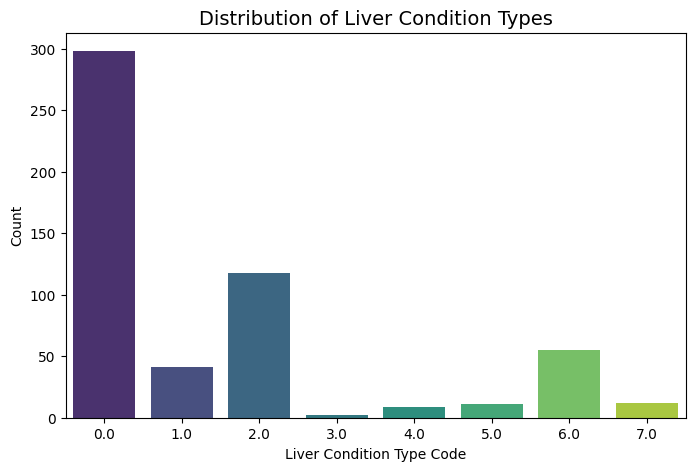

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Liver_condition_type', data=df_liver, palette='viridis')
plt.title('Distribution of Liver Condition Types', fontsize=14)
plt.xlabel('Liver Condition Type Code')
plt.ylabel('Count')
plt.show()

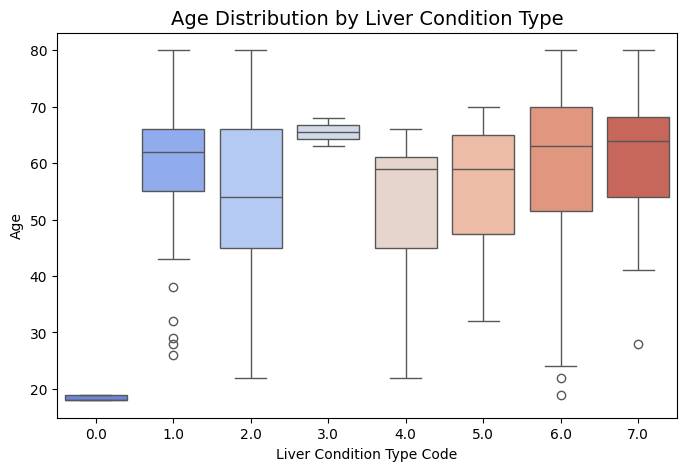

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Liver_condition_type', y='Age', data=df_liver, palette='coolwarm')
plt.title('Age Distribution by Liver Condition Type', fontsize=14)
plt.xlabel('Liver Condition Type Code')
plt.ylabel('Age')
plt.show()

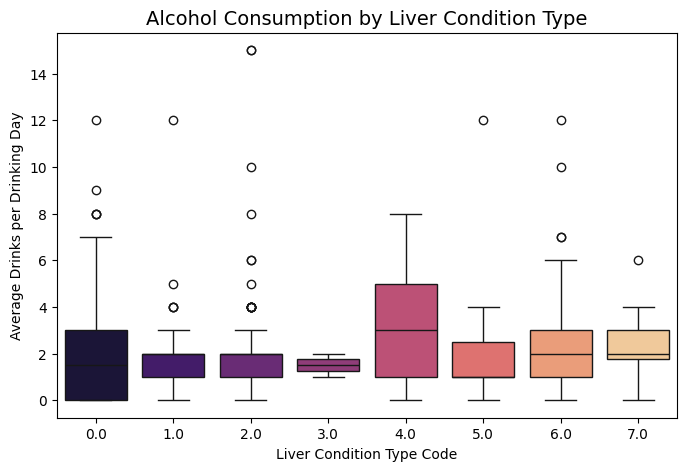

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Liver_condition_type', y='Average_Drinks_Per_Drinking_Day_Past_12_Months',
            data=df_liver, palette='magma')
plt.title('Alcohol Consumption by Liver Condition Type', fontsize=14)
plt.xlabel('Liver Condition Type Code')
plt.ylabel('Average Drinks per Drinking Day')
plt.show()

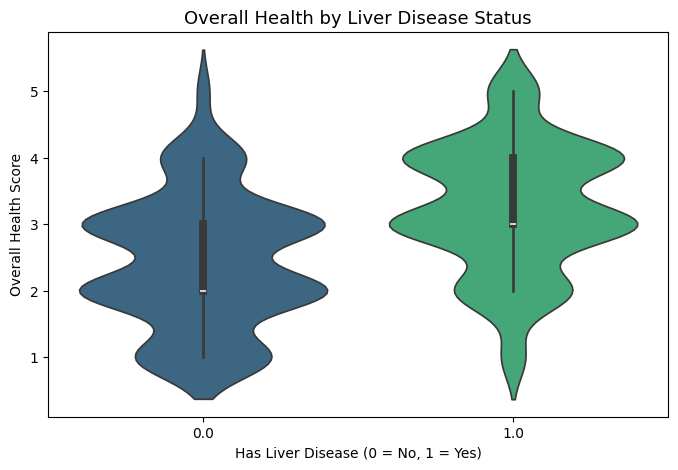

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Has_liver_disease', y='Overall_health', data=df_liver, palette='viridis')
plt.title('Overall Health by Liver Disease Status', fontsize=13)
plt.xlabel('Has Liver Disease (0 = No, 1 = Yes)')
plt.ylabel('Overall Health Score')
plt.show()

#CVD EDA

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df=pd.read_csv('/content/CVD_dataset_with_Bmi.csv')
df.shape

(2028, 16)

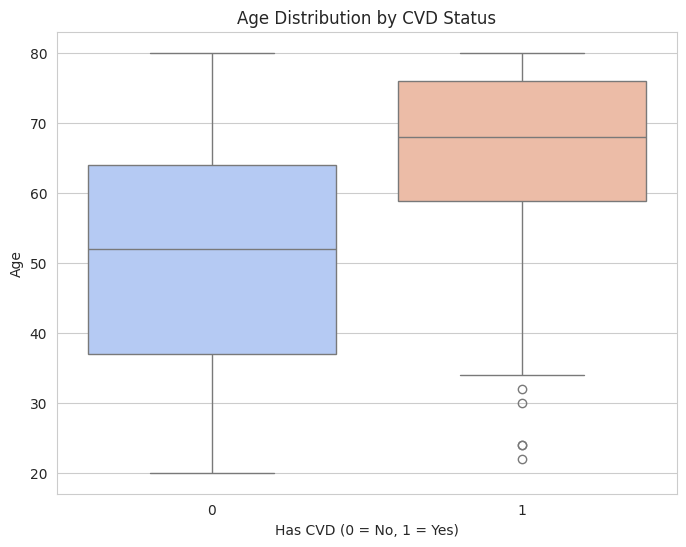

In [ ]:
sns.set_style("whitegrid")

# ===================================================================
# 1. Plots for Binary Outcome: Has_CVD (0 = No, 1 = Yes)
# ===================================================================

# --- Has_CVD vs. Age (Categorical vs. Continuous) ---
# A box plot is perfect for comparing distributions (like your Age vs. Liver Type plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Has_CVD', y='Age', data=df, palette="coolwarm")
plt.title('Age Distribution by CVD Status')
plt.xlabel('Has CVD (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

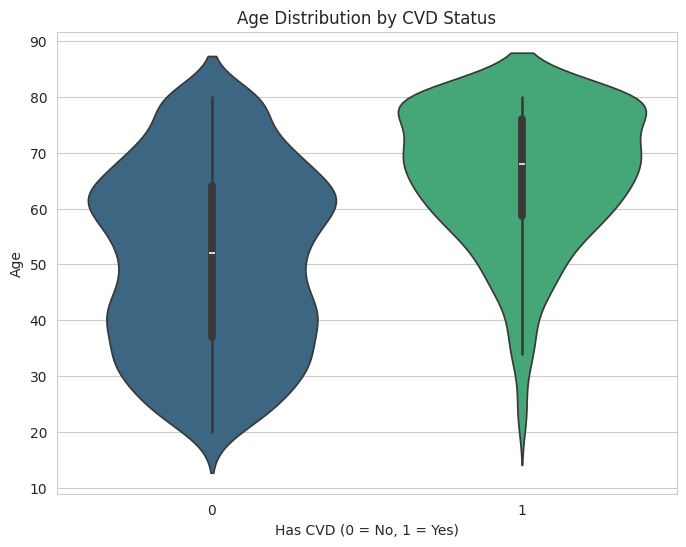

In [ ]:
# A violin plot is also a great alternative to see the shape of the data
plt.figure(figsize=(8, 6))
sns.violinplot(x='Has_CVD', y='Age', data=df, palette="viridis")
plt.title('Age Distribution by CVD Status')
plt.xlabel('Has CVD (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

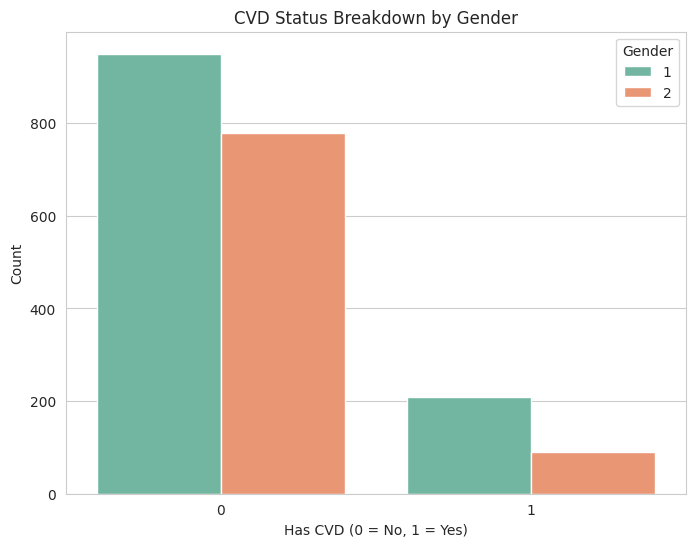

In [ ]:
# Has_CVD vs. Gender
plt.figure(figsize=(8, 6))
sns.countplot(x='Has_CVD', hue='Gender', data=df, palette="Set2")
plt.title('CVD Status Breakdown by Gender')
plt.xlabel('Has CVD (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

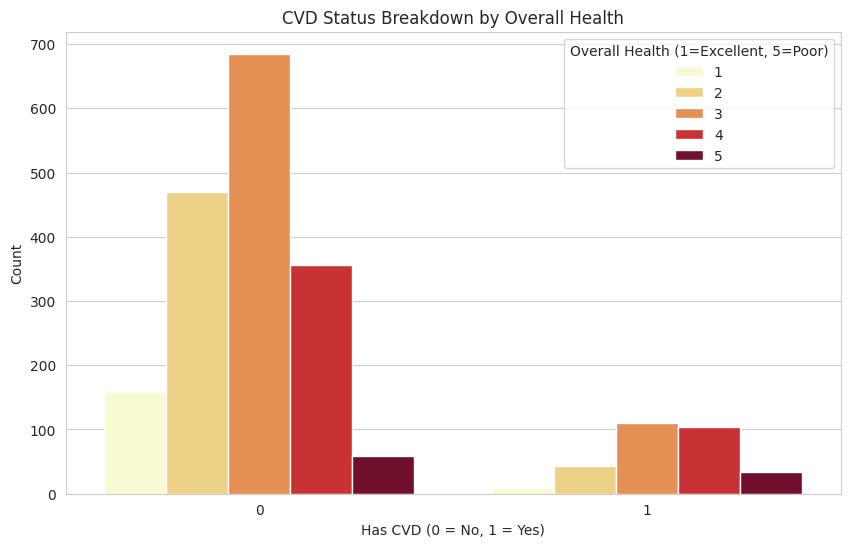

In [ ]:
# Has_CVD vs. Overall_health
plt.figure(figsize=(10, 6))
sns.countplot(x='Has_CVD', hue='Overall_health', data=df, palette="YlOrRd")
plt.title('CVD Status Breakdown by Overall Health')
plt.xlabel('Has CVD (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Overall Health (1=Excellent, 5=Poor)')
plt.show()

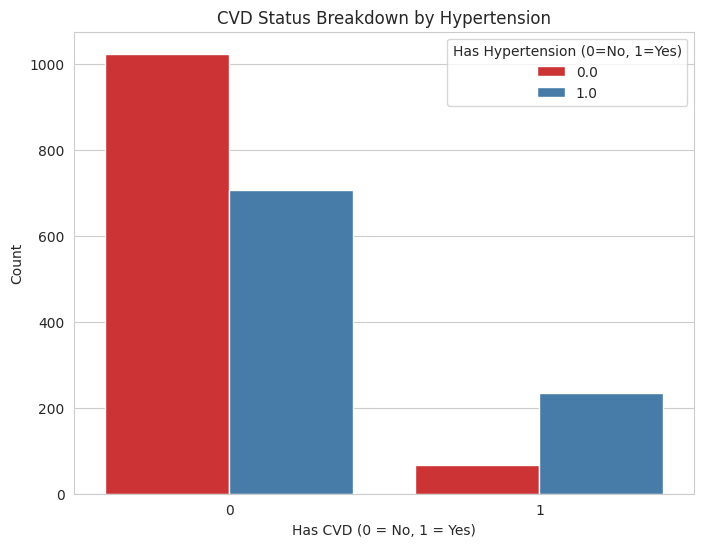

In [ ]:
# Has_CVD vs. Have_hypertension_or_highbp
plt.figure(figsize=(8, 6))
sns.countplot(x='Has_CVD', hue='Have_hypertension_or_highbp', data=df, palette="Set1")
plt.title('CVD Status Breakdown by Hypertension')
plt.xlabel('Has CVD (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Has Hypertension (0=No, 1=Yes)')
plt.show()

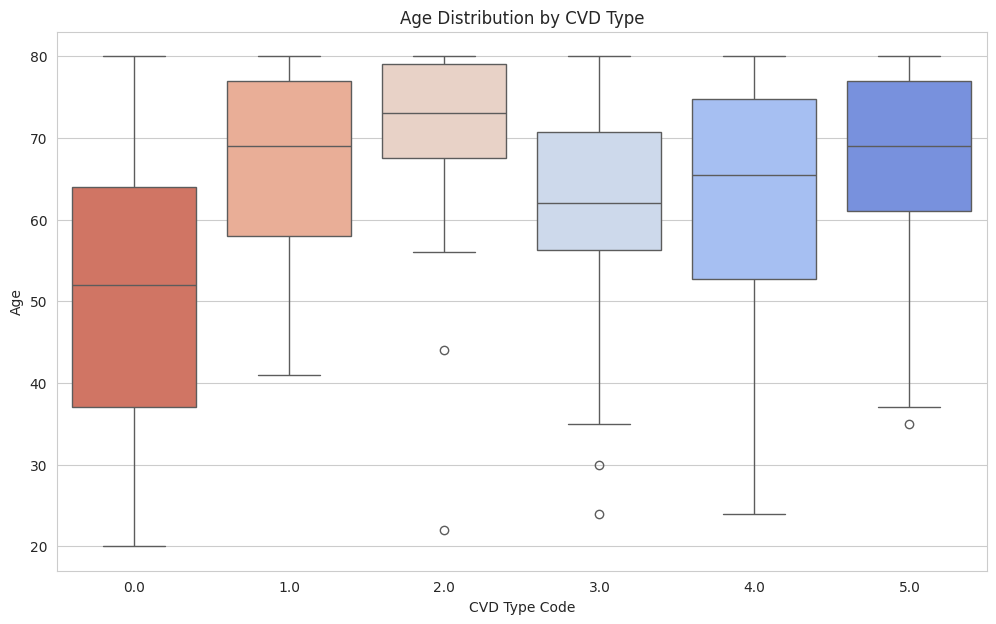

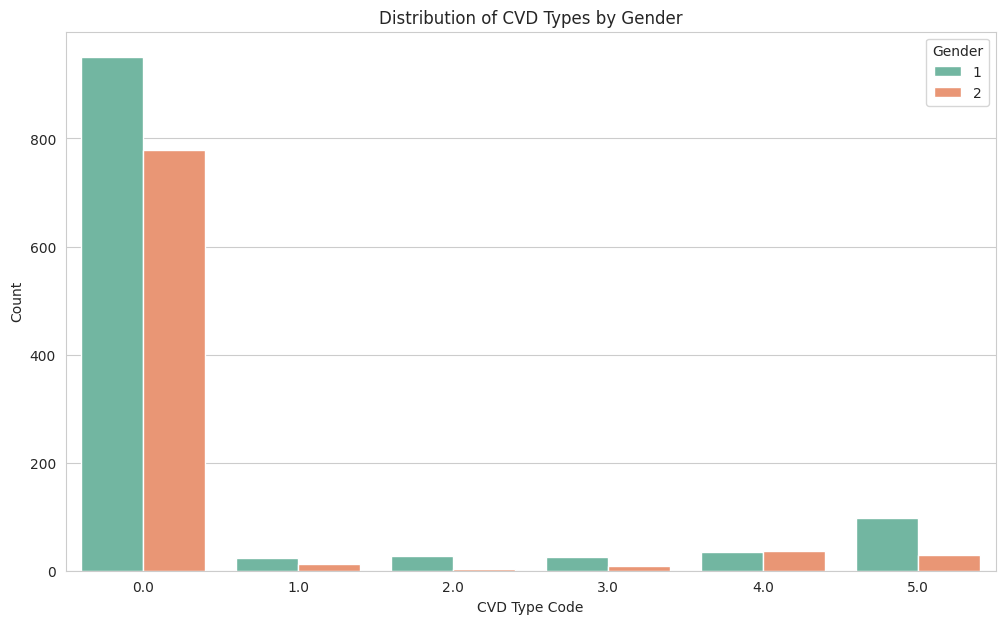

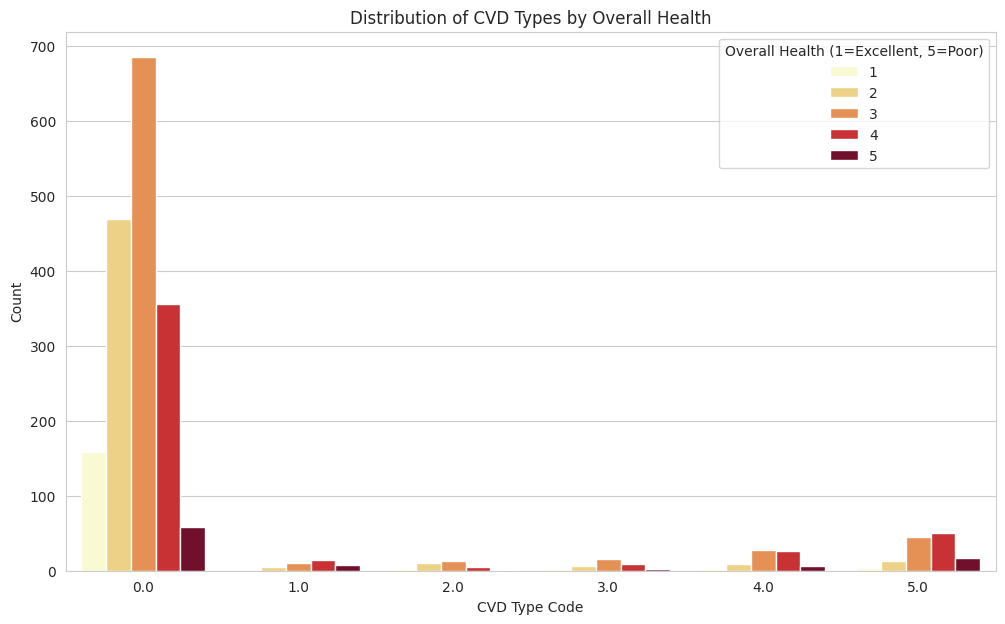

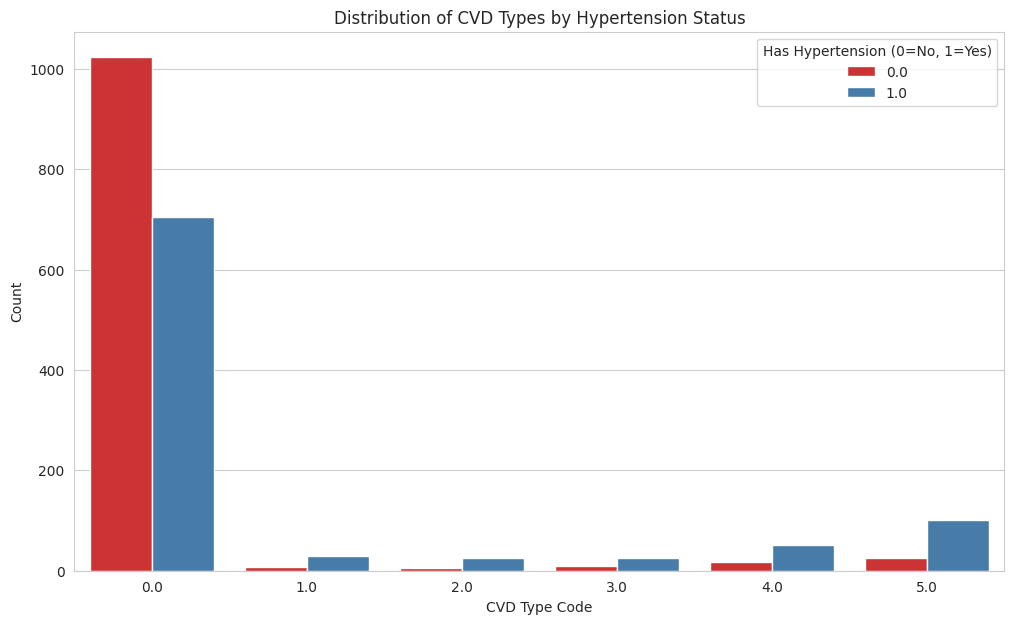

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='CVD_Type', y='Age', data=df, palette="coolwarm_r") # _r reverses the palette
plt.title('Age Distribution by CVD Type')
plt.xlabel('CVD Type Code')
plt.ylabel('Age')
plt.show()

# --- CVD_Type vs. Categorical Predictors (Gender, Health, Hypertension) ---
# We use count plots to see the composition of each CVD_Type

# CVD_Type vs. Gender
plt.figure(figsize=(12, 7))
sns.countplot(x='CVD_Type', hue='Gender', data=df, palette="Set2")
plt.title('Distribution of CVD Types by Gender')
plt.xlabel('CVD Type Code')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

# CVD_Type vs. Overall_health
plt.figure(figsize=(12, 7))
sns.countplot(x='CVD_Type', hue='Overall_health', data=df, palette="YlOrRd")
plt.title('Distribution of CVD Types by Overall Health')
plt.xlabel('CVD Type Code')
plt.ylabel('Count')
plt.legend(title='Overall Health (1=Excellent, 5=Poor)')
plt.show()

# CVD_Type vs. Have_hypertension_or_highbp
plt.figure(figsize=(12, 7))
sns.countplot(x='CVD_Type', hue='Have_hypertension_or_highbp', data=df, palette="Set1")
plt.title('Distribution of CVD Types by Hypertension Status')
plt.xlabel('CVD Type Code')
plt.ylabel('Count')
plt.legend(title='Has Hypertension (0=No, 1=Yes)')
plt.show()